# Mapping the self-similar-residual $\to$ matter-suppression calibration across feedback space

The "money plot" in `tsz_wl_calibration.ipynb` shows that, for **CV halos at fiducial
feedback**, a halo's deviation from the self-similar $Y$–$M$ relation,
$\Delta_{\rm SS}\equiv\log_{10}(Y_{200}/Y_{200}^{\rm SS})$ with
$Y_{200}^{\rm SS}=c_0 M_{200}^{5/3}$, predicts its **matter-power suppression**
$P_{\rm hydro}/P_{\rm DMO}$ at $k\approx10.4\,h/{\rm Mpc}$ (BIND slope $\alpha\approx+0.17$,
$\sigma_{\rm int}\approx0.086$).

Here we exploit BIND's ability to generate at **any** point in parameter space: the same
~1111 CV halos were regenerated across a **256-point Sobol grid in the 30 astrophysical
parameters** (cosmology fixed at the CV fiducial), via `sobol_ss_generation.py`. We refit the
$\Delta_{\rm SS}\!\to\!$suppression relation at every grid point and ask **which feedback knobs
tune the slope $\alpha$ (how strongly $Y$-deviation predicts suppression), the zero-point
$\beta$ (the typical suppression at the median deviation), and the intrinsic scatter
$\sigma_{\rm int}$.**

> Common random numbers: each design point reuses the same per-halo flow-matching noise, so
> design-to-design differences reflect parameters, not resampling noise.

## 0. Setup & load the Sobol cube

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import spearmanr

plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.grid': False})

CUBE = Path('/mnt/home/mlee1/ceph/sobol_ss_cv/cube.npz')        # full 256-pt run
if not CUBE.exists():
    CUBE = Path('/mnt/home/mlee1/ceph/sobol_ss_cv_dev/cube.npz')  # dev preview
print('Reading', CUBE)
z = np.load(CUBE, allow_pickle=True)
OBS = z['obs']                       # (n_design, n_halo, n_obs)
OBS_NAMES = list(z['obs_names'])
logM = np.log10(z['M200'].astype(float))   # (n_halo,) fixed SS mass anchor (catalog M200)
design_norm = z['design_norm']             # (n_design, 30) Sobol box coords in [0,1]
astro_names = list(z['astro_names'])
n_design, n_halo, n_obs = OBS.shape
print(f'designs={n_design}  halos={n_halo}  obs={OBS_NAMES}')

# short labels for the classic CAMELS knobs; ParamName otherwise
SHORT = {'WindEnergyIn1e51erg': 'A_SN1', 'VariableWindVelFactor': 'A_SN2',
         'RadioFeedbackFactor': 'A_AGN1', 'RadioFeedbackReiorientationFactor': 'A_AGN2'}
PLAB = [SHORT.get(n, n) for n in astro_names]
iY = OBS_NAMES.index('Y200')
iS = OBS_NAMES.index('supp_k10')

FIG = Path('tsz_ss_sobol_figs'); FIG.mkdir(exist_ok=True)
def savefig(fig, name):
    for e in ('pdf', 'png'):
        fig.savefig(FIG / f'{name}.{e}')
    print('wrote', FIG / f'{name}.png')

Reading /mnt/home/mlee1/ceph/sobol_ss_cv/cube.npz
designs=256  halos=1111  obs=['Y200', 'T', 'S', 'P', 'f_gas', 'm_gen', 'supp_k10', 'supp_prof']


## 1. Per-design self-similar-residual fit

At each design point we (i) fit the self-similar normalization $c_0$ with the slope fixed to
$5/3$ ($\log_{10}c_0=\langle\log_{10}Y-\tfrac53\log_{10}M\rangle$; cosmology is fixed so the
$\Omega_b/\Omega_M$ factor is an absorbed constant), (ii) form $\Delta_{\rm SS}$, and (iii) fit
$S=\alpha(\Delta_{\rm SS}-{\rm pivot})+\beta+\mathcal N(0,\sigma_{\rm int})$ by maximum
likelihood with $\sigma_{\rm int}$ a free parameter — the same procedure as `fig_money`.

In [3]:
def _design_arrays(d, s_name='supp_k10'):
    # per-halo Delta_SS and suppression for one design (cosmo fixed -> no Omega factor)
    Y = OBS[d, :, iY]
    S = OBS[d, :, OBS_NAMES.index(s_name)]
    base = np.isfinite(logM) & np.isfinite(Y) & (Y > 0)
    lY = np.full_like(logM, np.nan); lY[base] = np.log10(Y[base])
    logc0 = float(np.nanmean(lY[base] - (5 / 3) * logM[base]))
    xdev = np.full_like(logM, np.nan); xdev[base] = lY[base] - (logc0 + (5 / 3) * logM[base])
    return xdev, S, logc0

def fit_one_design(d, s_name='supp_k10'):
    xdev, S, _ = _design_arrays(d, s_name)
    m = np.isfinite(xdev) & np.isfinite(S)
    if m.sum() < 5:
        return None
    x, y = xdev[m], S[m]
    piv = float(np.median(x)); xx = x - piv
    def nll(th):
        a, b, ls = th
        s2 = np.exp(2 * ls); r = y - (a * xx + b)
        return 0.5 * np.sum(np.log(2 * np.pi * s2) + r * r / s2)
    a0, b0 = np.polyfit(xx, y, 1); s0 = float(np.std(y - (a0 * xx + b0))) + 1e-6
    res = minimize(nll, [a0, b0, np.log(s0)], method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-7})
    a, b, ls = res.x
    return dict(alpha=float(a), beta=float(b), sigma_int=float(np.exp(ls)),
                pivot=piv, median_S=float(np.median(y)),
                spearman=float(spearmanr(x, y).correlation), n=int(m.sum()))

fits = [fit_one_design(d) for d in range(n_design)]
fit_df = pd.DataFrame(fits)
for c in ['alpha', 'beta', 'sigma_int', 'median_S', 'spearman']:
    v = fit_df[c].values
    print(f'{c:10s} range [{np.nanmin(v):+.3f}, {np.nanmax(v):+.3f}]   median {np.nanmedian(v):+.3f}')

alpha      range [-0.004, +0.240]   median +0.119
beta       range [+0.690, +1.345]   median +0.897
sigma_int  range [+0.064, +0.190]   median +0.089
median_S   range [+0.688, +1.322]   median +0.882
spearman   range [-0.040, +0.442]   median +0.236


## 2. The calibration moves across parameter space

The four panels show the actual $\Delta_{\rm SS}$–suppression scatter (colored by halo mass)
at the design points with the **extreme** fitted slope $\alpha$ and zero-point $\beta$ — i.e.
the corners of feedback space where the law is steepest/flattest and where suppression is
strongest/weakest.

wrote tsz_ss_sobol_figs/ss_money_panels.png


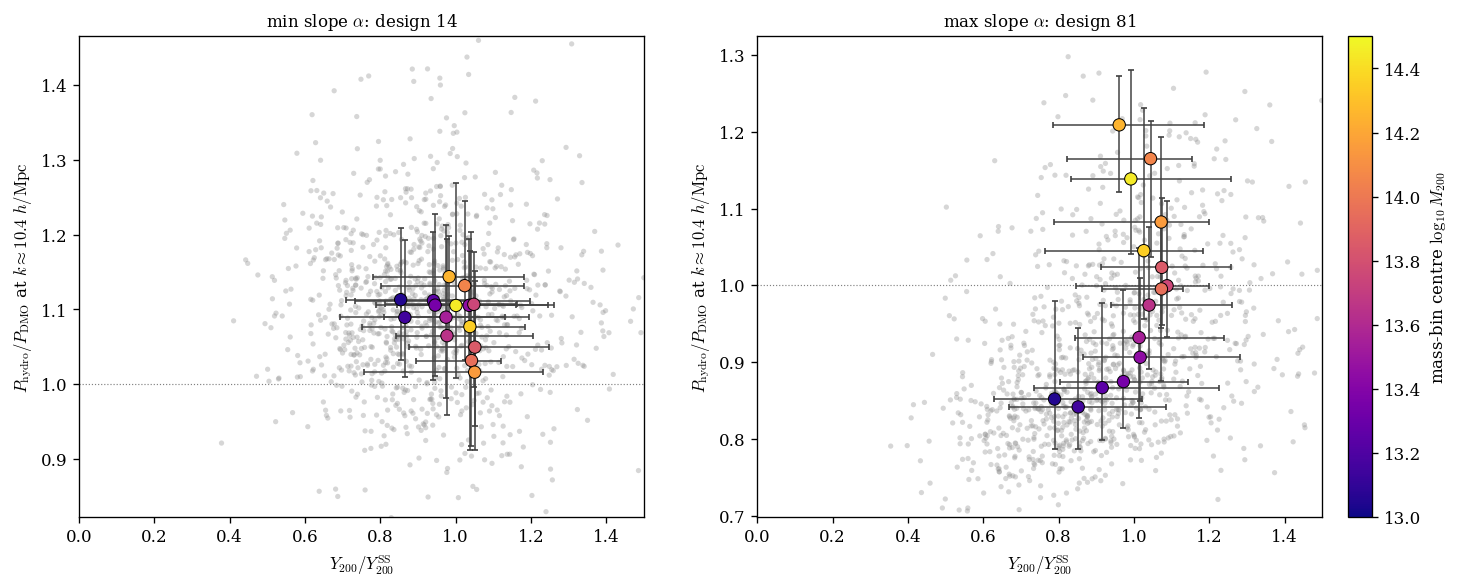

In [4]:
# Money plot across feedback (mirroring tsz_wl_calibration.ipynb):
#   - x-axis is Y_200 / Y_200^SS (c0 fitted on logM >= 14.0);
#   - faint grey halo cloud + 15 fixed mass-bin medians coloured by bin-centre mass,
#     with x & y 16-84% errorbars in dark grey.
# Two panels = flattest vs steepest Y->S slope across the Sobol grid; both panels
# share styling and a single mass colourbar.

from matplotlib.colors import Normalize

SCATTER_COLOR = '0.55'    # light grey halo cloud
BIN_CMAP      = 'plasma'  # mass-bin medians coloured by bin-centre log10 M200


def _fit_yss_design(logM_arr, Y_arr, min_logM_fit=14.0):
    """c0 fit log10(Y) = log10(c0) + (5/3) log10(M) on the high-mass subset."""
    base = np.isfinite(logM_arr) & np.isfinite(Y_arr) & (Y_arr > 0)
    m_fit = base & (logM_arr >= min_logM_fit)
    if m_fit.sum() < 5:
        return float('nan'), np.full(logM_arr.shape, np.nan, float), 0
    logc0 = float(np.mean(np.log10(Y_arr[m_fit]) - (5.0 / 3.0) * logM_arr[m_fit]))
    c0 = float(10 ** logc0)
    y_ss = np.full(logM_arr.shape, np.nan, float)
    y_ss[base] = c0 * (10 ** logM_arr[base]) ** (5.0 / 3.0)
    return c0, y_ss, int(m_fit.sum())


def _fixed_mass_binned_xy_stats(lm, x, y, mmin=13.0, mmax=14.5, n_bins=15):
    """Per-bin medians and 16-84% errors for both x and y in fixed mass bins."""
    lm = np.asarray(lm, float); x = np.asarray(x, float); y = np.asarray(y, float)
    edges = np.linspace(mmin, mmax, n_bins + 1)
    out = {k: np.full(n_bins, np.nan, float) for k in
           ('x', 'y', 'xerr_lo', 'xerr_hi', 'yerr_lo', 'yerr_hi')}
    out['mbin'] = 0.5 * (edges[:-1] + edges[1:])
    out['n'] = np.zeros(n_bins, int)
    for i in range(n_bins):
        sel = (lm >= edges[i]) & ((lm < edges[i + 1]) if i < n_bins - 1 else (lm <= edges[i + 1]))
        sel &= np.isfinite(x) & np.isfinite(y)
        out['n'][i] = int(sel.sum())
        if out['n'][i] == 0:
            continue
        xv, yv = x[sel], y[sel]
        xm, ym = float(np.nanmedian(xv)), float(np.nanmedian(yv))
        x16, x84 = np.nanpercentile(xv, [16, 84])
        y16, y84 = np.nanpercentile(yv, [16, 84])
        out['x'][i] = xm; out['y'][i] = ym
        out['xerr_lo'][i] = xm - float(x16); out['xerr_hi'][i] = float(x84) - xm
        out['yerr_lo'][i] = ym - float(y16); out['yerr_hi'][i] = float(y84) - ym
    return out


def _money_panel(ax, d, label, mass_norm,
                 min_logM_fit=14.0, bin_range=(13.0, 14.5), n_mass_bins=15):
    Y = OBS[d, :, iY].astype(float)
    S = OBS[d, :, iS].astype(float)
    M = logM.astype(float)

    _, y_ss, _ = _fit_yss_design(M, Y, min_logM_fit=min_logM_fit)
    with np.errstate(divide='ignore', invalid='ignore'):
        x_ratio = np.where((Y > 0) & (y_ss > 0), Y / y_ss, np.nan)

    m = np.isfinite(S) & np.isfinite(x_ratio)
    ax.scatter(x_ratio[m], S[m], s=10, alpha=0.35, color=SCATTER_COLOR,
               edgecolors='none')

    bs = _fixed_mass_binned_xy_stats(M, x_ratio, S,
                                     mmin=bin_range[0], mmax=bin_range[1],
                                     n_bins=n_mass_bins)
    mb = np.isfinite(bs['x']) & np.isfinite(bs['y'])
    # Errorbars first (no marker), then mass-coloured scatter on top so the dots
    # are visible above the errorbar caps.
    ax.errorbar(bs['x'][mb], bs['y'][mb],
                xerr=np.vstack([bs['xerr_lo'][mb], bs['xerr_hi'][mb]]),
                yerr=np.vstack([bs['yerr_lo'][mb], bs['yerr_hi'][mb]]),
                fmt='none', ecolor='0.25',
                elinewidth=0.9, capsize=2.0, zorder=3)
    sc = ax.scatter(bs['x'][mb], bs['y'][mb], c=bs['mbin'][mb],
                    cmap=BIN_CMAP, norm=mass_norm,
                    s=55, edgecolor='k', linewidth=0.6, zorder=4)

    ax.axhline(1.0, color='0.5', lw=0.7, ls=':')
    ax.set_xlabel(r'$Y_{200}/Y_{200}^{\rm SS}$')
    ax.set_title(f'{label}: design {d}', fontsize=10)

    # Per-panel data-driven y-limits with a small margin; fixed x-range.
    if m.any():
        y_lo = float(np.nanpercentile(S[m], 1))
        y_hi = float(np.nanpercentile(S[m], 99))
        ypad = 0.05 * (y_hi - y_lo + 1e-6)
        ax.set_xlim(0, 1.5)
        ax.set_ylim(y_lo - ypad, y_hi + ypad)
    return sc


# Pick the two ends of the feedback span: flattest vs steepest Y->S slope.
order_a = np.argsort(fit_df['alpha'].values)
d_lo, d_hi = int(order_a[0]), int(order_a[-1])

MASS_RANGE = (13.0, 14.5)
mass_norm = Normalize(vmin=MASS_RANGE[0], vmax=MASS_RANGE[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))   # no sharey: each panel autoscales
sc = _money_panel(axes[0], d_lo, label=r'min slope $\alpha$',
                  mass_norm=mass_norm, bin_range=MASS_RANGE)
_money_panel(axes[1], d_hi, label=r'max slope $\alpha$',
             mass_norm=mass_norm, bin_range=MASS_RANGE)
for ax in axes:
    ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$ at $k\approx10.4\ h/\mathrm{Mpc}$')
fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.02,
             label=r'mass-bin centre $\log_{10} M_{200}$')
savefig(fig, 'ss_money_panels')
plt.show()


### 2a. One halo across all 256 designs

The money panel shows 1111 halos at one feedback design. Here we transpose: pick **one halo**
and trace where it sits in the $(Y_{200}/Y_{200}^{\rm SS},\,P_{\rm hydro}/P_{\rm DMO})$ plane
as feedback varies across the 256-point Sobol cube. Because the same per-halo flow-matching
noise is reused at every design, the cloud is *common-random-numbers feedback response* — no
resampling jitter, only parameter response.

The SS normalization $c_0$ is refit per design (high-mass anchor, $\log_{10}M_{200}\ge 14$),
exactly as in the money panel above.

/tmp/ipykernel_960681/3919209086.py:25: RuntimeWarning: divide by zero encountered in log10
  _box_fid = np.where(_plog == 1, np.log10(_pfid), _pfid)
/tmp/ipykernel_960681/3919209086.py:25: RuntimeWarning: invalid value encountered in log10
  _box_fid = np.where(_plog == 1, np.log10(_pfid), _pfid)


fiducial in normalized box: median |u_fid - 0.5| = 0.500
design-to-fiducial distance: range [2.23, 3.43], median 2.81  (max possible = sqrt(30) = 5.48)
wrote tsz_ss_sobol_figs/ss_money_single_halo.png


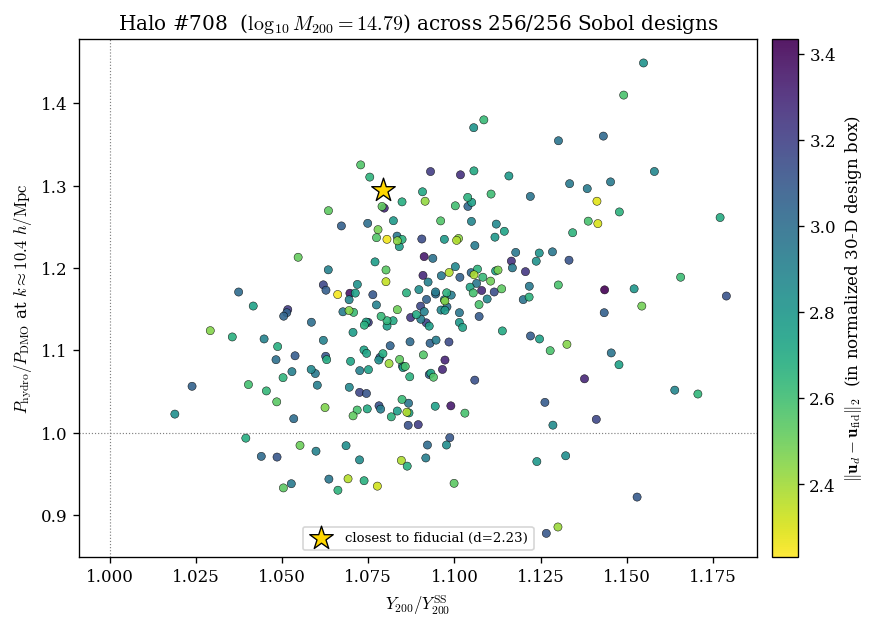

In [7]:
# Per-design (Y/Y_SS, suppression) trajectories for a single halo across all 256 designs.
# Default: pick the most massive halo (most informative); set HALO_IDX to override.
# Points are coloured by Euclidean distance from the CV fiducial in the *normalized*
# design box (the same [0,1]^30 Sobol coordinate the generator inverted into physical
# units via the SB35 min/max table with per-param log-flag), so all 30 knobs enter on
# an equal footing.

SB35_CSV = Path('/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')
_meta = pd.read_csv(SB35_CSV)
_pname_all = _meta['ParamName'].tolist()
_pmin_all = _meta['MinVal'].to_numpy(float)
_pmax_all = _meta['MaxVal'].to_numpy(float)
_plog_all = _meta['LogFlag'].to_numpy(int)
_pfid_all = _meta['FiducialVal'].to_numpy(float)

# Map astro_names (order used in the cube) -> rows in the SB35 table.
_idx_astro = np.array([_pname_all.index(n) for n in astro_names], dtype=int)
_pmin = _pmin_all[_idx_astro]; _pmax = _pmax_all[_idx_astro]
_plog = _plog_all[_idx_astro]; _pfid = _pfid_all[_idx_astro]

# Same inversion the generator uses (sobol_ss_generation.build_design):
#   box   = pmin + u * (pmax - pmin)        # log10 in log-flag columns
#   phys  = 10**box for log_flag==1, else box
# So in the *normalized* box (u in [0,1]^30) the fiducial is:
_box_fid = np.where(_plog == 1, np.log10(_pfid), _pfid)
u_fid = (_box_fid - _pmin) / (_pmax - _pmin)
# Clip just in case the catalogue fiducial sits a hair outside the SB35 box.
u_fid = np.clip(u_fid, 0.0, 1.0)

# Euclidean distance in the normalized box (per-parameter range = 1 by construction).
design_dist = np.linalg.norm(design_norm - u_fid[None, :], axis=1)
print(f'fiducial in normalized box: median |u_fid - 0.5| = {np.median(np.abs(u_fid - 0.5)):.3f}')
print(f'design-to-fiducial distance: range [{design_dist.min():.2f}, {design_dist.max():.2f}], '
      f'median {np.median(design_dist):.2f}  (max possible = sqrt(30) = {np.sqrt(30):.2f})')


def _per_design_ratio_and_supp_for_halo(h):
    """Return arrays of length n_design: Y/Y_SS and suppression for halo h."""
    x = np.full(n_design, np.nan); s = np.full(n_design, np.nan)
    for d in range(n_design):
        Y_d = OBS[d, :, iY].astype(float)
        S_d = OBS[d, :, iS].astype(float)
        _, y_ss_d, _ = _fit_yss_design(logM.astype(float), Y_d, min_logM_fit=14.0)
        if np.isfinite(Y_d[h]) and Y_d[h] > 0 and np.isfinite(y_ss_d[h]) and y_ss_d[h] > 0:
            x[d] = Y_d[h] / y_ss_d[h]
        s[d] = S_d[h]
    return x, s


HALO_IDX = int(np.argmax(logM))   # most massive halo by default
x_h, s_h = _per_design_ratio_and_supp_for_halo(HALO_IDX)
m = np.isfinite(x_h) & np.isfinite(s_h)

fig, ax = plt.subplots(figsize=(7.8, 5.6))
# Plot farthest-from-fiducial points first so the near-fiducial designs sit on top.
order = np.argsort(-design_dist[m])
xs = x_h[m][order]; ys = s_h[m][order]; cs = design_dist[m][order]
sc = ax.scatter(xs, ys, c=cs, s=24, cmap='viridis_r',
                edgecolor='k', linewidth=0.3, alpha=0.9)

# Mark the nearest-to-fiducial design with a star for orientation.
i_fid = int(np.nanargmin(design_dist[m]))
ax.scatter([xs[-1]], [ys[-1]], marker='*', s=220, facecolor='gold',
           edgecolor='k', linewidth=0.8, zorder=6,
           label=f'closest to fiducial (d={design_dist[m].min():.2f})')

ax.axhline(1.0, color='0.5', lw=0.7, ls=':')
ax.axvline(1.0, color='0.5', lw=0.7, ls=':')
ax.set_xlabel(r'$Y_{200}/Y_{200}^{\rm SS}$')
ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$ at $k\approx10.4\ h/\mathrm{Mpc}$')
ax.set_title(rf'Halo #{HALO_IDX}  ($\log_{{10}} M_{{200}} = {logM[HALO_IDX]:.2f}$) '
             f'across {int(m.sum())}/{n_design} Sobol designs')
ax.legend(fontsize=8, loc='best')
fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02,
             label=r'$\|\mathbf{u}_d - \mathbf{u}_{\rm fid}\|_2$  '
                   r'(in normalized 30-D design box)')
savefig(fig, 'ss_money_single_halo')
plt.show()


### 2b. Mass-bin medians across all 256 designs

Same idea, but with the 15 fixed mass-bin median points from the money panel: at each design we
compute the bin median $(Y/Y_{\rm SS},\,S)$ in the same $[13.0, 14.5]$ bins, then plot the full
$15\times 256$ track set. Each mass bin becomes a cloud of 256 points coloured by bin-centre
mass — collapsing per-halo scatter and exposing how the *binned money plot itself* migrates
through feedback space.

In [ ]:
# Mass-bin median (Y/Y_SS, suppression) trajectories across all 256 designs.
# One cloud per mass bin, coloured by bin-centre mass — same bins as the money panel.

MASS_RANGE = (13.0, 14.5)
N_MASS_BINS = 15
mass_norm = Normalize(vmin=MASS_RANGE[0], vmax=MASS_RANGE[1])
mbin_centers = 0.5 * (np.linspace(*MASS_RANGE, N_MASS_BINS + 1)[:-1]
                      + np.linspace(*MASS_RANGE, N_MASS_BINS + 1)[1:])

# (n_design, n_bins) tables of bin-median x and y
x_bin = np.full((n_design, N_MASS_BINS), np.nan)
y_bin = np.full((n_design, N_MASS_BINS), np.nan)
for d in range(n_design):
    Y_d = OBS[d, :, iY].astype(float)
    S_d = OBS[d, :, iS].astype(float)
    _, y_ss_d, _ = _fit_yss_design(logM.astype(float), Y_d, min_logM_fit=14.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        x_ratio = np.where((Y_d > 0) & (y_ss_d > 0), Y_d / y_ss_d, np.nan)
    bs = _fixed_mass_binned_xy_stats(logM, x_ratio, S_d,
                                     mmin=MASS_RANGE[0], mmax=MASS_RANGE[1],
                                     n_bins=N_MASS_BINS)
    x_bin[d] = bs['x']
    y_bin[d] = bs['y']

fig, axes = plt.subplots(3, 5, figsize=(17, 9), sharex=True, sharey=True)
# Shared axis limits = global 1-99 percentile across all bin trajectories.
finite_x = np.isfinite(x_bin); finite_y = np.isfinite(y_bin)
x_lo, x_hi = np.nanpercentile(x_bin[finite_x], [1, 99])
y_lo, y_hi = np.nanpercentile(y_bin[finite_y], [1, 99])
x_pad = 0.05 * (x_hi - x_lo + 1e-9); y_pad = 0.05 * (y_hi - y_lo + 1e-9)

# Per-design colour shared across all panels: distance to fiducial in normalized box.
# (Falls back gracefully if `design_dist` wasn't built in 2a.)
try:
    _color_d = design_dist
    _clabel = (r'$\|\mathbf{u}_d - \mathbf{u}_{\rm fid}\|_2$  '
               r'(in normalized 30-D design box)')
    _cmap = 'viridis_r'
except NameError:
    _color_d = np.arange(n_design, dtype=float)
    _clabel = 'design index'
    _cmap = 'viridis'

sc = None
for b, ax in enumerate(axes.ravel()):
    if b >= N_MASS_BINS:
        ax.axis('off'); continue
    mb = np.isfinite(x_bin[:, b]) & np.isfinite(y_bin[:, b])
    n_b = int(mb.sum())
    if n_b == 0:
        ax.set_title(rf'$\log_{{10}}M_{{200}} = {mbin_centers[b]:.2f}$  (empty)',
                     fontsize=9)
        ax.axis('off'); continue
    # Plot designs ordered so near-fiducial points sit on top of far ones.
    order = np.argsort(-_color_d[mb])
    sc = ax.scatter(x_bin[mb, b][order], y_bin[mb, b][order],
                    c=_color_d[mb][order], cmap=_cmap, s=18,
                    edgecolor='none', alpha=0.85)
    # Design-median anchor and bin-centre-mass marker (consistent with money panel).
    ax.scatter([np.nanmedian(x_bin[:, b])], [np.nanmedian(y_bin[:, b])],
               c=[mbin_centers[b]], cmap=BIN_CMAP, norm=mass_norm,
               s=110, edgecolor='k', linewidth=0.8, zorder=5)
    ax.axhline(1.0, color='0.5', lw=0.6, ls=':')
    ax.axvline(1.0, color='0.5', lw=0.6, ls=':')
    ax.set_title(rf'$\log_{{10}}M_{{200}} = {mbin_centers[b]:.2f}$   '
                 f'(n_des={n_b})', fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel(r'bin-median $Y_{200}/Y_{200}^{\rm SS}$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'bin-median $P_{\rm hydro}/P_{\rm DMO}\ (k\approx10.4)$')
axes[0, 0].set_xlim(x_lo - x_pad, x_hi + x_pad)
axes[0, 0].set_ylim(y_lo - y_pad, y_hi + y_pad)

if sc is not None:
    fig.colorbar(sc, ax=axes, fraction=0.018, pad=0.02, label=_clabel)
fig.suptitle(f'Mass-bin trajectories across {n_design} Sobol designs '
             '(one panel = one mass bin; bold marker = design-median)',
             y=1.00, fontsize=11)
savefig(fig, 'ss_money_massbin_tracks_grid')
plt.show()


In [ ]:
## 2b. Per-halo feedback-response matrix — *which halos carry the signal?*

The money plot collapses 1111 halos into one law per design. But because each Sobol design
reuses **the same 1111 halos with the same flow-matching noise**, we have something rarer: a
clean per-halo response curve $S_i(\boldsymbol\theta)$ across the 256-point design.  Fitting a
standardised linear surrogate per halo,

$$Z_i(\boldsymbol\theta) = \mathbf{s}_i\cdot \tilde{\boldsymbol\theta} + \varepsilon_i,$$

gives a **per-halo sensitivity vector** $\mathbf{s}_i\in\mathbb{R}^{30}$ (one number per
feedback knob), an **amplitude** $\|\mathbf{s}_i\|$ (how loudly that halo's suppression reacts
to feedback at all), and a **direction** $\hat{\mathbf{s}}_i$ (which knobs it cares about).
This matrix $\mathbf{S}\in\mathbb{R}^{N_{\rm halo}\times 30}$ is the object the rest of this
section mines.

We use the configuration-space metric `supp_prof` (tighter per-halo than the $k\approx10.4$
Fourier ratio); both metrics give the same qualitative picture.
<VSCode.Cell language="markdown">
### Figure 1 — Are all halos equally informative?

Per-halo response amplitude $\|\mathbf{s}_i\|$ vs the four properties most likely to predict
where feedback "bites": halo mass, formation redshift, DMO-derived concentration ($c_V$ from
the assembly table), and the design-median gas fraction. If a small subset of halos carries most
of the signal, the histogram is fat-tailed and the scatter panels pick out *which* halos those
are — directly informative for which targets a tSZ / X-ray stack should prioritise.
<VSCode.Cell language="markdown">
### Figure 2 — How many independent feedback modes do halos see?

SVD of the centred sensitivity matrix $\mathbf{S} = U\Sigma V^\top$ asks **how many directions
in 30-D feedback space halos actually use**. If the spectrum drops fast, baryonic feedback is
*effectively low-dimensional from a halo's point of view* — the rigorous version of every
"baryonification" paper's assumption that 1–2 free parameters suffice. The right panel shows
the loadings of the top-2 modes on the 30 knobs (the classic CAMELS knobs $A_{\rm SN1,2}$,
$A_{\rm AGN1,2}$ are labelled by their short names; the other 26 IllustrisTNG sub-grid
parameters carry their raw `ParamName`).


### Figure 3 — Assembly-conditioned response: do early- and late-forming halos use different knobs?

Splitting halos by formation redshift $z_{\rm form}$ tests whether the **direction** of the
feedback response (not just its amplitude) depends on assembly history. Two complementary
views: (a) the mean per-knob sensitivity for early- vs late-forming quartiles, with paired
error bars; (b) the **angle between the top response modes** of the two strata, plus the
$z_{\rm form}$-resolved Spearman correlation of $\|\mathbf{s}_i\|$ with each of the 30 knobs to
expose knobs whose importance flips with assembly. A non-zero angle and any sign-flipping knobs
in (b) are the signature of **assembly bias of the baryonic response** — a result with direct
consequences for mass-only baryon-mitigation priors used in weak-lensing analyses.

In [15]:
# Build the per-halo feedback-response matrix S (n_halo x 30) from common-random-numbers.
# Standardise X (design knobs) and Y (each halo's suppression curve) so S is SRC-like.
iSp_resp = OBS_NAMES.index('supp_prof')
Y_resp = OBS[:, :, iSp_resp].astype(float)                          # (n_design, n_halo)

Xz = (design_norm - design_norm.mean(0)) / (design_norm.std(0) + 1e-12)   # (n_design, 30)
Y_mean = np.nanmean(Y_resp, axis=0, keepdims=True)
Y_std  = np.nanstd(Y_resp, axis=0, keepdims=True) + 1e-12
Yz = np.where(np.isfinite(Y_resp), (Y_resp - Y_mean) / Y_std, 0.0)

# Drop halos with too many missing designs
n_finite = np.isfinite(Y_resp).sum(0)
keep = n_finite >= int(0.9 * n_design)

# OLS per halo (batched): S = (Xz^T Xz)^-1 Xz^T Yz
XtX_inv = np.linalg.pinv(Xz.T @ Xz)
S_mat = (XtX_inv @ (Xz.T @ Yz)).T                                    # (n_halo, 30)
S_mat[~keep] = np.nan

# Per-halo amplitude, direction, and linear-surrogate R^2
s_amp = np.linalg.norm(np.nan_to_num(S_mat), axis=1)
s_amp[~keep] = np.nan
Yhat = Xz @ np.nan_to_num(S_mat).T
ss_res = np.nansum((Yz - Yhat) ** 2, axis=0)
ss_tot = np.nansum(Yz ** 2, axis=0)
R2_halo = 1.0 - ss_res / (ss_tot + 1e-12)
R2_halo[~keep] = np.nan

# Load assembly table (1:1 with the cube)
ATAB = np.load(CUBE.parent / 'assembly_table.npz', allow_pickle=True)
assert np.nanmax(np.abs(ATAB['M200'] - z['M200'])) == 0, 'assembly rows must match the cube'
ASM = ATAB['feats']; ASM_NAMES = list(ATAB['feat_names'])
iZF = ASM_NAMES.index('z_form'); iCV = ASM_NAMES.index('c_V')
print('assembly features:', ASM_NAMES)

# Design-median per-halo f_gas as a "typical-feedback" proxy (cosmology is fixed)
fgas_typ = np.nanmedian(OBS[:, :, OBS_NAMES.index('f_gas')], axis=0)

print(f'kept halos: {int(keep.sum())}/{n_halo}')
print(f'|s|        range [{np.nanmin(s_amp):.2f}, {np.nanmax(s_amp):.2f}]   median {np.nanmedian(s_amp):.2f}')
print(f'R^2(halo)  range [{np.nanmin(R2_halo):+.2f}, {np.nanmax(R2_halo):+.2f}]   median {np.nanmedian(R2_halo):+.2f}')


assembly features: ['c_V', 'lambda', 'veldisp', 'rhalf', 'z_form']
kept halos: 1111/1111
|s|        range [0.31, 0.90]   median 0.83
R^2(halo)  range [+0.09, +0.82]   median +0.67


### Sanity check — is $\|\mathbf{s}_i\|$ really "information"?

The standardised amplitude above answers "what fraction of halo $i$'s **own** variance is
explained per unit knob change". It does *not* answer "how much does halo $i$ contribute to the
population suppression signal", because it divides out the per-halo response standard deviation
$\sigma_Y(i)$. A small galaxy-group halo whose suppression wiggles by $\pm0.01$ across the
Sobol grid, perfectly tracking AGN1, gets the same $\|s\|$ as a cluster whose suppression
wiggles by $\pm0.3$.

To recover the physical-units "information per halo" we look at
$A_i \equiv \|s_i\|\,\sigma_Y(i)$ — the response amplitude in actual suppression units. If
group/cluster halos dominate feedback as standard physical intuition says they must, $A_i$
should rise steeply with mass and its Lorenz curve should be very concave.


A_phys = |s|*sigma_Y  range [0.003, 0.081]   median 0.030   max/median = 2.7x
  top  5% most massive halos carry 0.4% of sum A_phys^2  (and 28.6% of total mass)
  top 10% most massive halos carry 1.5% of sum A_phys^2  (and 40.6% of total mass)
  top 25% most massive halos carry 8.7% of sum A_phys^2  (and 60.8% of total mass)
Physical-units SVD: PR = 2.08  (vs SRC-units PR = 2.70), modes for 90% = 3
wrote tsz_ss_sobol_figs/ss_perhalo_physical_units.png


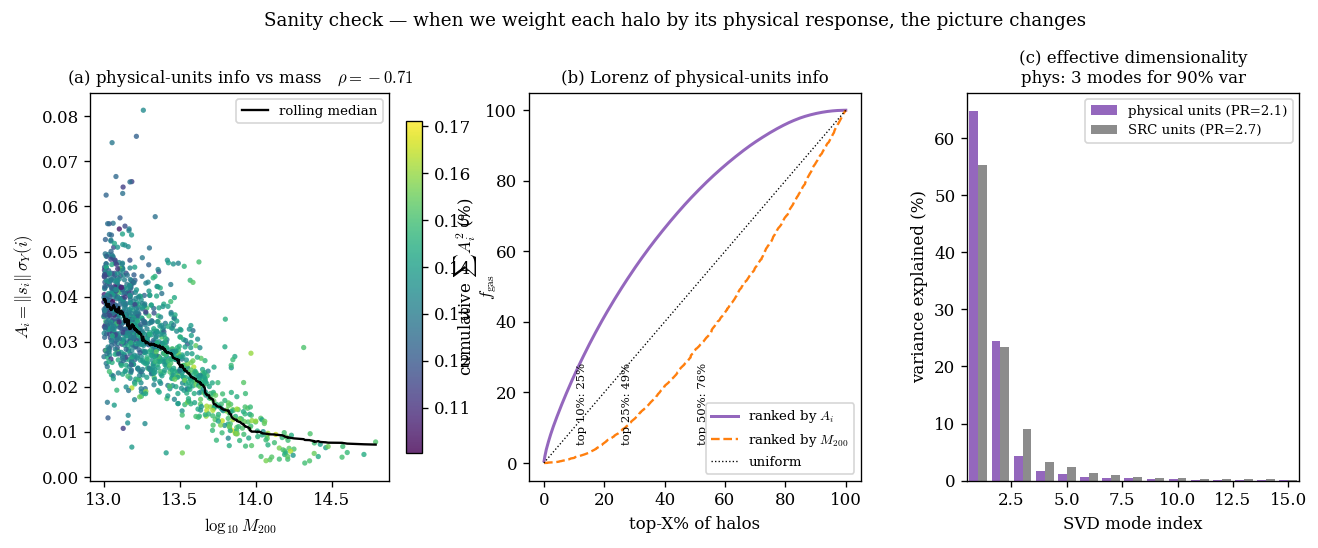

In [19]:
# Physical-units per-halo information: A_i = |s_i| * sigma_Y(i)
# (un-do the per-halo Y standardisation done in the previous cell)
sigma_Y = Y_std.ravel()                          # (n_halo,) physical-unit response std
A_phys  = s_amp * sigma_Y                        # |s| * sigma_Y -> physical "info per halo"
A_phys[~keep] = np.nan

# Also rebuild a physical-units sensitivity matrix and redo the SVD: this is the
# operator that maps a feedback perturbation to the *population mean* suppression,
# which is what an observer actually measures.
S_phys = S_mat * sigma_Y[:, None]                # (n_halo, 30) in suppression units
S_phys_kept = S_phys[keep]
S_phys_cent = S_phys_kept - S_phys_kept.mean(0, keepdims=True)
_, Sv_p, Vt_p = np.linalg.svd(S_phys_cent, full_matrices=False)
vf_p = Sv_p ** 2 / np.sum(Sv_p ** 2)
PR_phys = 1.0 / np.sum(vf_p ** 2)
n90_p = int(np.searchsorted(np.cumsum(vf_p), 0.90) + 1)

# Mass-share of A_phys: do the top-X% most massive halos carry most of the signal?
mass = 10 ** logM
ord_mass = np.argsort(-mass)
A_sorted = A_phys[ord_mass]
finite = np.isfinite(A_sorted)
A_finite = A_sorted[finite]
mass_finite = mass[ord_mass][finite]
cum_A_by_mass = np.cumsum(A_finite ** 2) / np.sum(A_finite ** 2)
cum_M_by_mass = np.cumsum(mass_finite) / np.sum(mass_finite)
print(f'A_phys = |s|*sigma_Y  range [{np.nanmin(A_phys):.3f}, {np.nanmax(A_phys):.3f}]   '
      f'median {np.nanmedian(A_phys):.3f}   max/median = '
      f'{np.nanmax(A_phys)/np.nanmedian(A_phys):.1f}x')
for q in (0.05, 0.10, 0.25):
    k_ = int(q * len(A_finite))
    print(f'  top {int(100*q):>2d}% most massive halos carry {100*cum_A_by_mass[k_]:.1f}% of '
          f'sum A_phys^2  (and {100*cum_M_by_mass[k_]:.1f}% of total mass)')
print(f'Physical-units SVD: PR = {PR_phys:.2f}  (vs SRC-units PR = {PR:.2f}), '
      f'modes for 90% = {n90_p}')

# --- figure ---
fig = plt.figure(figsize=(13, 4.2))
gs = fig.add_gridspec(1, 3, wspace=0.32)

# (a) A_phys vs mass, coloured by f_gas_typ
ax = fig.add_subplot(gs[0, 0])
m = np.isfinite(A_phys)
sc = ax.scatter(logM[m], A_phys[m], c=fgas_typ[m], cmap='viridis',
                s=10, alpha=0.8, edgecolor='none')
order = np.argsort(logM[m]); xs = logM[m][order]; ys = A_phys[m][order]
w = max(20, len(xs) // 20)
med = np.array([np.median(ys[max(0, i - w):i + w + 1]) for i in range(len(xs))])
ax.plot(xs, med, color='k', lw=1.4, label='rolling median')
rho_M = spearmanr(logM[m], A_phys[m]).correlation
ax.set_xlabel(r'$\log_{10} M_{200}$'); ax.set_ylabel(r'$A_i = \|s_i\|\,\sigma_Y(i)$')
ax.set_title(f'(a) physical-units info vs mass   $\\rho={rho_M:+.2f}$', fontsize=10)
ax.legend(fontsize=8); plt.colorbar(sc, ax=ax, fraction=0.05, label=r'$f_{\rm gas}$')

# (b) Lorenz of A_phys^2: rank halos by their own A_phys, descending
ax = fig.add_subplot(gs[0, 1])
A_pos = A_phys[np.isfinite(A_phys)]
ord_A = np.argsort(-A_pos)
cumA = np.cumsum(A_pos[ord_A] ** 2) / np.sum(A_pos[ord_A] ** 2)
frac = np.arange(1, len(A_pos) + 1) / len(A_pos)
ax.plot(100 * frac, 100 * cumA, lw=1.8, color='tab:purple', label='ranked by $A_i$')
# overlay: cumulative by descending mass (does mass-ranking suffice?)
ax.plot(100 * np.arange(1, len(A_finite) + 1) / len(A_finite),
        100 * cum_A_by_mass, lw=1.4, color='tab:orange', ls='--',
        label='ranked by $M_{200}$')
ax.plot([0, 100], [0, 100], 'k:', lw=0.8, label='uniform')
for q in (0.1, 0.25, 0.5):
    k_ = int(q * len(A_pos))
    ax.text(100 * q + 1, 5, f'top {int(100*q)}%: {100*cumA[k_]:.0f}%',
            rotation=90, fontsize=7, va='bottom')
ax.set_xlabel('top-X% of halos'); ax.set_ylabel(r'cumulative $\sum A_i^2$ (%)')
ax.set_title('(b) Lorenz of physical-units info', fontsize=10)
ax.legend(fontsize=8, loc='lower right')

# (c) Physical-units SVD spectrum, vs SRC-units for reference
ax = fig.add_subplot(gs[0, 2])
k_ = np.arange(1, len(Sv_p) + 1)
w = 0.4
ax.bar(k_ - w/2, vf_p * 100, width=w, color='tab:purple',
       label=f'physical units (PR={PR_phys:.1f})')
ax.bar(k_ + w/2, var_frac * 100, width=w, color='0.55',
       label=f'SRC units (PR={PR:.1f})')
ax.set_xlim(0.5, min(15, len(Sv_p)) + 0.5)
ax.set_xlabel('SVD mode index'); ax.set_ylabel('variance explained (%)')
ax.set_title(f'(c) effective dimensionality\nphys: {n90_p} modes for 90% var', fontsize=10)
ax.legend(fontsize=8)

fig.suptitle('Sanity check — when we weight each halo by its physical response, the picture changes',
             y=1.04, fontsize=11)
savefig(fig, 'ss_perhalo_physical_units'); plt.show()


wrote tsz_ss_sobol_figs/ss_perhalo_amplitude.png


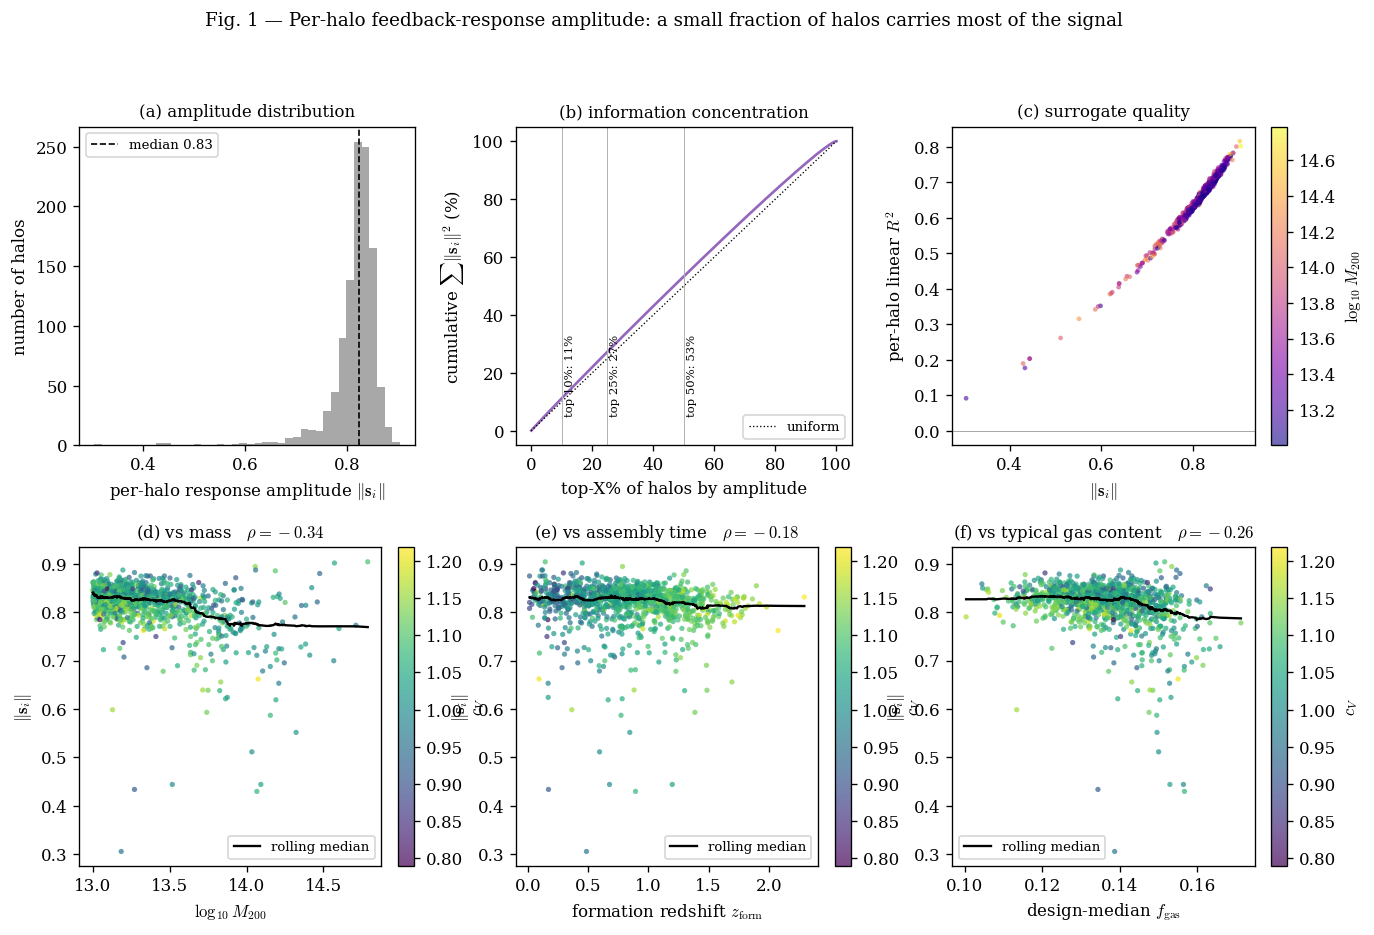

In [16]:
# Fig 1 — distribution of per-halo response amplitude + stratification by halo properties
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, hspace=0.32, wspace=0.30)

# (a) amplitude histogram, with running cumulative information share
ax = fig.add_subplot(gs[0, 0])
amp = s_amp[np.isfinite(s_amp)]
ax.hist(amp, bins=40, color='0.6', alpha=0.85)
ax.axvline(np.median(amp), color='k', ls='--', lw=1, label=f'median {np.median(amp):.2f}')
ax.set_xlabel(r'per-halo response amplitude $\|\mathbf{s}_i\|$')
ax.set_ylabel('number of halos')
ax.legend(fontsize=8)
ax.set_title('(a) amplitude distribution', fontsize=10)

# (b) Lorenz-like cumulative information share: do few halos carry most of the |s|^2?
ax = fig.add_subplot(gs[0, 1])
ord_ = np.argsort(-amp)
cum = np.cumsum(amp[ord_] ** 2) / np.sum(amp[ord_] ** 2)
frac = np.arange(1, len(amp) + 1) / len(amp)
ax.plot(100 * frac, 100 * cum, lw=1.6, color='tab:purple')
ax.plot([0, 100], [0, 100], 'k:', lw=0.8, label='uniform')
for q in (0.1, 0.25, 0.5):
    k_ = int(q * len(amp))
    ax.axvline(100 * q, color='0.7', lw=0.6)
    ax.text(100 * q + 1, 5, f'top {int(100*q)}%: {100*cum[k_]:.0f}%',
            rotation=90, fontsize=7, va='bottom')
ax.set_xlabel('top-X% of halos by amplitude')
ax.set_ylabel(r'cumulative $\sum\|\mathbf{s}_i\|^2$ (%)')
ax.legend(fontsize=8, loc='lower right')
ax.set_title('(b) information concentration', fontsize=10)

# (c) per-halo linear-R^2 vs amplitude — does the linear surrogate work where it matters?
ax = fig.add_subplot(gs[0, 2])
m = np.isfinite(s_amp) & np.isfinite(R2_halo)
sc = ax.scatter(s_amp[m], R2_halo[m], c=logM[m], cmap='plasma', s=8, alpha=0.6,
                edgecolor='none')
ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel(r'$\|\mathbf{s}_i\|$')
ax.set_ylabel(r'per-halo linear $R^2$')
ax.set_title('(c) surrogate quality', fontsize=10)
plt.colorbar(sc, ax=ax, fraction=0.05, label=r'$\log_{10}M_{200}$')

# (d-f) amplitude vs (mass, z_form, fiducial f_gas), colored by c_V
covars = [(logM,            r'$\log_{10}M_{200}$',           'mass'),
          (ASM[:, iZF],     r'formation redshift $z_{\rm form}$', 'assembly time'),
          (fgas_typ,        r'design-median $f_{\rm gas}$',  'typical gas content')]
for col, (xv, xlab, ttl) in enumerate(covars):
    ax = fig.add_subplot(gs[1, col])
    m = np.isfinite(s_amp) & np.isfinite(xv) & np.isfinite(ASM[:, iCV])
    sc = ax.scatter(xv[m], s_amp[m], c=ASM[m, iCV], cmap='viridis',
                    s=10, alpha=0.7, edgecolor='none')
    # rolling median for the eye
    order = np.argsort(xv[m])
    xs = xv[m][order]; ys = s_amp[m][order]
    w = max(20, len(xs) // 20)
    med = np.array([np.median(ys[max(0, i - w):i + w + 1]) for i in range(len(xs))])
    ax.plot(xs, med, color='k', lw=1.4, label='rolling median')
    rho = spearmanr(xv[m], s_amp[m]).correlation
    ax.set_xlabel(xlab); ax.set_ylabel(r'$\|\mathbf{s}_i\|$')
    ax.set_title(f'({"def"[col]}) vs {ttl}   $\\rho={rho:+.2f}$', fontsize=10)
    ax.legend(fontsize=8, loc='best')
    plt.colorbar(sc, ax=ax, fraction=0.05, label=r'$c_V$')

fig.suptitle('Fig. 1 — Per-halo feedback-response amplitude: a small fraction of halos '
             'carries most of the signal', y=1.00, fontsize=11)
savefig(fig, 'ss_perhalo_amplitude'); plt.show()


modes for 90% var = 4, for 95% = 7, participation ratio = 2.70
wrote tsz_ss_sobol_figs/ss_sensitivity_svd.png


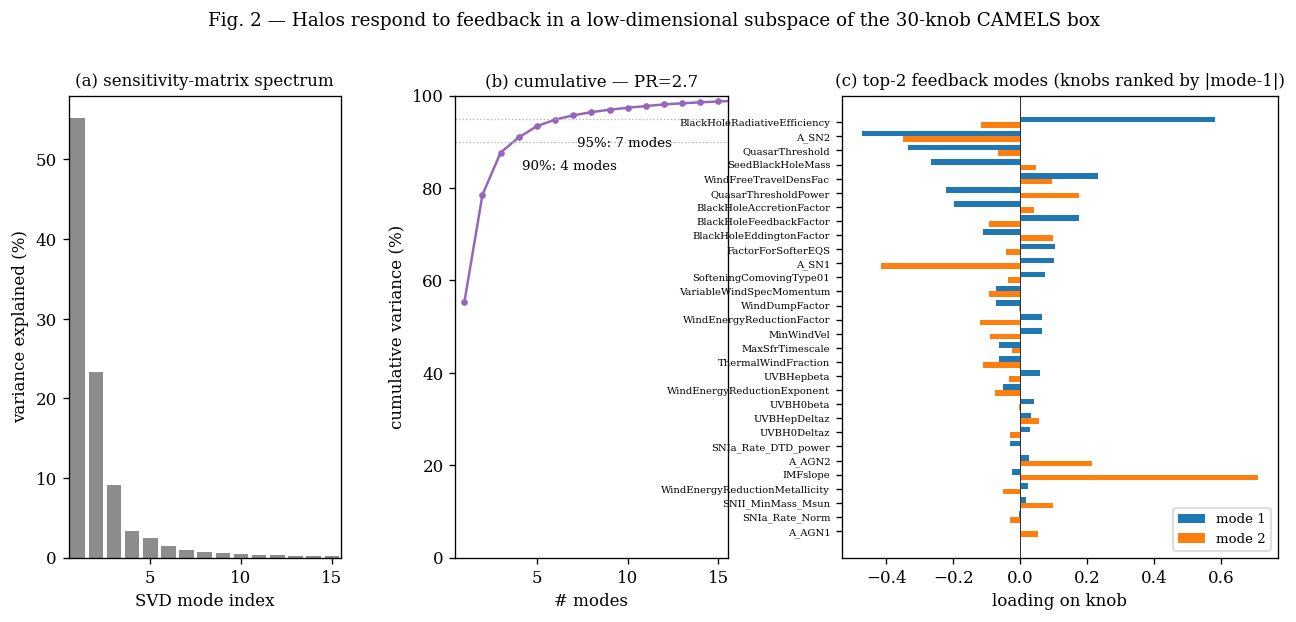

In [17]:
# Fig 2 — SVD of the per-halo sensitivity matrix: effective dimensionality of feedback
S_kept = S_mat[keep]                                  # (n_kept, 30)
S_cent = S_kept - S_kept.mean(0, keepdims=True)
U, Sv, Vt = np.linalg.svd(S_cent, full_matrices=False)
var_frac = Sv ** 2 / np.sum(Sv ** 2)
cum_var = np.cumsum(var_frac)
n_eff_90 = int(np.searchsorted(cum_var, 0.90) + 1)
n_eff_95 = int(np.searchsorted(cum_var, 0.95) + 1)
# participation ratio: 1 / sum(p_i^2) where p_i = sigma_i^2 / sum
PR = 1.0 / np.sum(var_frac ** 2)
print(f'modes for 90% var = {n_eff_90}, for 95% = {n_eff_95}, participation ratio = {PR:.2f}')

fig = plt.figure(figsize=(13, 5.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 1.6], wspace=0.35)

# (a) spectrum
ax = fig.add_subplot(gs[0, 0])
k_ = np.arange(1, len(Sv) + 1)
ax.bar(k_, var_frac * 100, color='0.55')
ax.set_xlabel('SVD mode index'); ax.set_ylabel('variance explained (%)')
ax.set_title('(a) sensitivity-matrix spectrum', fontsize=10)
ax.set_xlim(0.5, min(15, len(Sv)) + 0.5)

# (b) cumulative
ax = fig.add_subplot(gs[0, 1])
ax.plot(k_, cum_var * 100, marker='o', ms=3, color='tab:purple')
for thr, lab in [(90, '90%'), (95, '95%')]:
    ax.axhline(thr, color='0.7', lw=0.8, ls=':')
    nthr = int(np.searchsorted(cum_var, thr / 100) + 1)
    ax.text(nthr + 0.2, thr - 6, f'{lab}: {nthr} modes', fontsize=8)
ax.set_xlabel('# modes'); ax.set_ylabel('cumulative variance (%)')
ax.set_xlim(0.5, min(15, len(Sv)) + 0.5); ax.set_ylim(0, 100)
ax.set_title(f'(b) cumulative — PR={PR:.1f}', fontsize=10)

# (c) loadings of top-2 modes on the 30 knobs
ax = fig.add_subplot(gs[0, 2])
order = np.argsort(-np.abs(Vt[0]))
y = np.arange(len(PLAB))
w = 0.4
ax.barh(y - w / 2, Vt[0][order], height=w, color='tab:blue', label='mode 1')
ax.barh(y + w / 2, Vt[1][order], height=w, color='tab:orange', label='mode 2')
ax.set_yticks(y); ax.set_yticklabels([PLAB[i] for i in order], fontsize=6)
ax.axvline(0, color='0.2', lw=0.6)
ax.invert_yaxis()
ax.set_xlabel('loading on knob')
ax.set_title('(c) top-2 feedback modes (knobs ranked by |mode-1|)', fontsize=10)
ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Fig. 2 — Halos respond to feedback in a low-dimensional subspace of the 30-knob CAMELS box',
             y=1.02, fontsize=11)
savefig(fig, 'ss_sensitivity_svd'); plt.show()


early (z_form>=1.15): N=278   late (z_form<=0.52): N=278
No knob flips sign at >1 SE; assembly bias is amplitude/direction, not sign.
wrote tsz_ss_sobol_figs/ss_assembly_conditioned_response.png


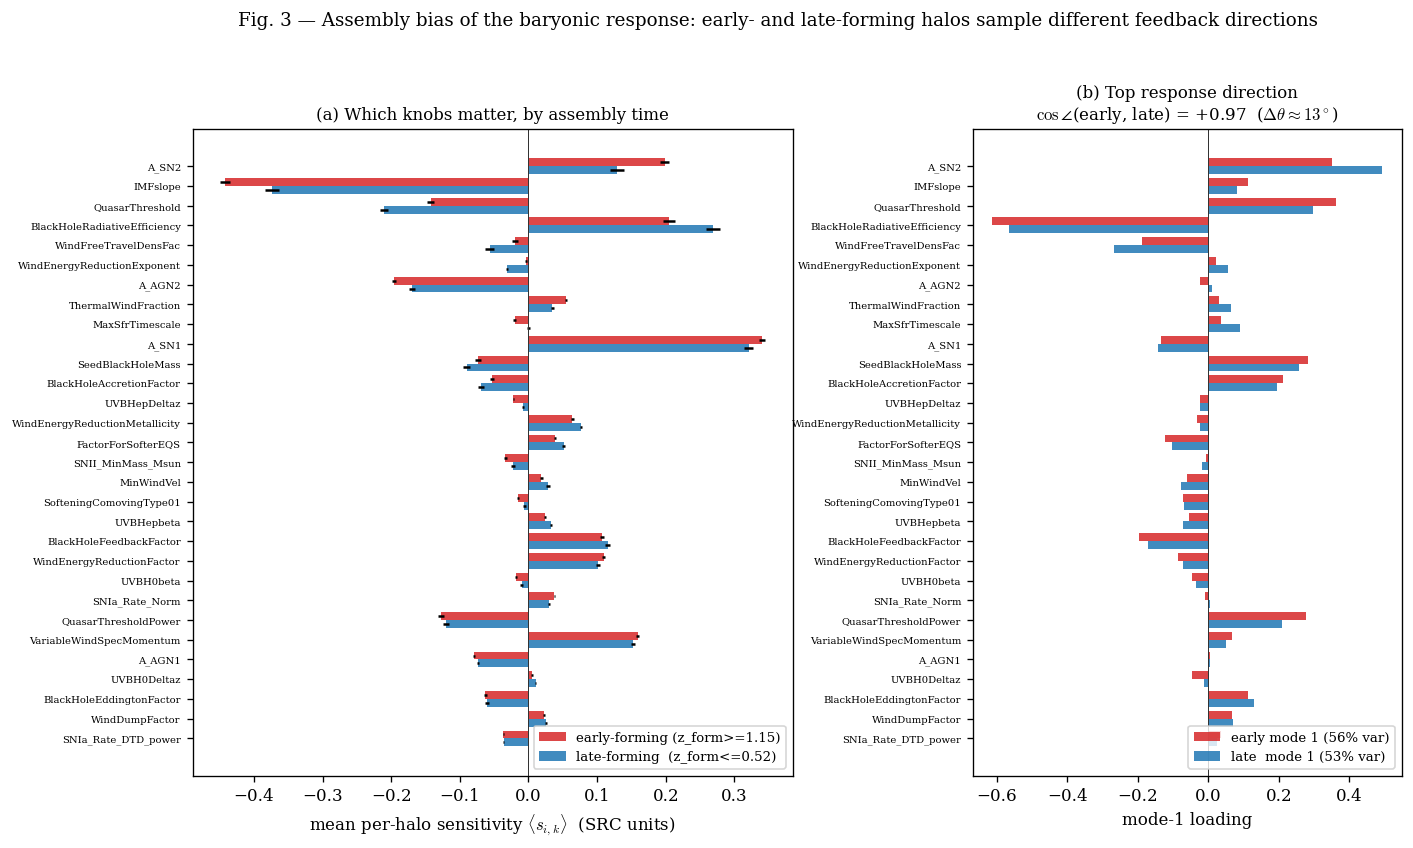

In [18]:
# Fig 3 — assembly-conditioned response: split halos by z_form quartiles
zf = ASM[:, iZF]
mvalid = keep & np.isfinite(zf)
q25, q50, q75 = np.nanpercentile(zf[mvalid], [25, 50, 75])
early = mvalid & (zf >= q75)            # high z_form  -> early forming
late  = mvalid & (zf <= q25)            # low  z_form  -> late forming
print(f'early (z_form>={q75:.2f}): N={early.sum()}   late (z_form<={q25:.2f}): N={late.sum()}')

def _mean_se(M):
    mu = np.nanmean(M, axis=0)
    se = np.nanstd(M, axis=0, ddof=1) / np.sqrt(np.isfinite(M).sum(0))
    return mu, se

mu_e, se_e = _mean_se(S_mat[early])
mu_l, se_l = _mean_se(S_mat[late])

# Top response mode for each stratum (right singular vector of centred S)
def _top_mode(M):
    Mc = M - np.nanmean(M, axis=0, keepdims=True)
    Mc = np.nan_to_num(Mc)
    _, sv, vt = np.linalg.svd(Mc, full_matrices=False)
    return vt[0], sv[0] ** 2 / np.sum(sv ** 2)

v_e, vf_e = _top_mode(S_mat[early])
v_l, vf_l = _top_mode(S_mat[late])
# Fix sign so they are comparable (align v_l to v_e)
if np.dot(v_e, v_l) < 0:
    v_l = -v_l
cos_ang = float(np.dot(v_e, v_l) / (np.linalg.norm(v_e) * np.linalg.norm(v_l) + 1e-12))
ang_deg = np.degrees(np.arccos(np.clip(np.abs(cos_ang), 0, 1)))

# Rank knobs by the *difference* in mean sensitivity between early and late
diff = mu_e - mu_l
order = np.argsort(-np.abs(diff))

fig = plt.figure(figsize=(13, 7.0))
gs = fig.add_gridspec(1, 2, width_ratios=[1.4, 1.0], wspace=0.35)

# (a) paired mean-sensitivity bars, knobs ordered by |early - late|
ax = fig.add_subplot(gs[0, 0])
y = np.arange(len(PLAB))
w = 0.4
ax.barh(y - w / 2, mu_e[order], xerr=se_e[order], height=w,
        color='tab:red',  alpha=0.85, label=f'early-forming (z_form>={q75:.2f})')
ax.barh(y + w / 2, mu_l[order], xerr=se_l[order], height=w,
        color='tab:blue', alpha=0.85, label=f'late-forming  (z_form<={q25:.2f})')
ax.set_yticks(y); ax.set_yticklabels([PLAB[i] for i in order], fontsize=6)
ax.axvline(0, color='0.2', lw=0.6); ax.invert_yaxis()
ax.set_xlabel(r'mean per-halo sensitivity $\langle s_{i,k}\rangle$  (SRC units)')
ax.set_title('(a) Which knobs matter, by assembly time', fontsize=10)
ax.legend(fontsize=8, loc='lower right')

# (b) top response modes overlaid; annotate angle and explained variance
ax = fig.add_subplot(gs[0, 1])
ax.barh(y - w / 2, v_e[order], height=w, color='tab:red',  alpha=0.85,
        label=f'early mode 1 ({100*vf_e:.0f}% var)')
ax.barh(y + w / 2, v_l[order], height=w, color='tab:blue', alpha=0.85,
        label=f'late  mode 1 ({100*vf_l:.0f}% var)')
ax.set_yticks(y); ax.set_yticklabels([PLAB[i] for i in order], fontsize=6)
ax.axvline(0, color='0.2', lw=0.6); ax.invert_yaxis()
ax.set_xlabel('mode-1 loading')
ax.set_title(f'(b) Top response direction\n'
             rf'$\cos\angle$(early, late) = {cos_ang:+.2f}  ($\Delta\theta\approx{ang_deg:.0f}^\circ$)',
             fontsize=10)
ax.legend(fontsize=8, loc='lower right')

# Print sign-flippers
sign_flip = (np.sign(mu_e) != np.sign(mu_l)) & (np.abs(mu_e) > se_e) & (np.abs(mu_l) > se_l)
if sign_flip.any():
    print('Knobs whose mean sensitivity FLIPS SIGN between early and late strata:')
    for k in np.where(sign_flip)[0]:
        print(f'  {PLAB[k]:30s}  early={mu_e[k]:+.3f}+-{se_e[k]:.3f}   '
              f'late={mu_l[k]:+.3f}+-{se_l[k]:.3f}')
else:
    print('No knob flips sign at >1 SE; assembly bias is amplitude/direction, not sign.')

fig.suptitle('Fig. 3 — Assembly bias of the baryonic response: early- and late-forming halos '
             'sample different feedback directions', y=1.02, fontsize=11)
savefig(fig, 'ss_assembly_conditioned_response'); plt.show()


## 3. Sensitivity — which feedback knobs tune the law?

We regress each fit parameter on the 30 (standardized) astro knobs using the **shared
sensitivity toolkit** `scatter.sensitivity` (the same engine as the BIND scatter analysis on
`analysis/2d`, so the driver definitions match across the two analyses). **Standardized
regression coefficients (SRC)** are the primary estimator and the model-free **distance
correlation** is the cross-check. Rather than *assuming* the response is smooth enough for SRC,
`cv_r2_compare` measures it: 5-fold out-of-sample $R^2$ for a linear model vs gradient boosting
(GBM). The decisive comparison is **linear vs GBM** — when boosting buys almost nothing over a
linear fit (gap $\lesssim0.05$ here), the response is near-linear and SRC is a faithful summary.
Bootstrap CIs are over the design points; a coefficient is flagged significant when its 16–84%
interval excludes zero.

In [4]:
# Sensitivity estimators are now the SHARED toolkit from the scatter package
# (scatter/sensitivity.py) — the same SRC / distance-correlation engine used by the
# BIND scatter analysis (analysis/2d). Using it here guarantees the driver heatmaps
# in both analyses share an identical definition, and gives us cv_r2_compare: the
# out-of-sample linear-vs-GP-vs-GBM check that *justifies* SRC rather than assuming it.
from scatter.sensitivity import src_bootstrap, distance_correlation, dcor_all, cv_r2_compare
dcor = distance_correlation  # alias kept for the cells below

TARGETS = ['alpha', 'beta', 'sigma_int', 'median_S']
SRC = np.full((len(PLAB), len(TARGETS)), np.nan)
SRC_lo = SRC.copy(); SRC_hi = SRC.copy()
R2 = {}        # in-sample linear SRC R^2 (the SRC fit itself)
CV_R2 = {}     # out-of-sample 5-fold R^2 for linear / GP / GBM surrogates
for j, t in enumerate(TARGETS):
    yt = fit_df[t].values
    beta, r2, lo, hi = src_bootstrap(design_norm, yt, n_boot=500)   # note: (beta, R2, lo, hi)
    SRC[:, j], SRC_lo[:, j], SRC_hi[:, j] = beta, lo, hi
    R2[t] = r2
    CV_R2[t] = cv_r2_compare(design_norm, yt)
    s = CV_R2[t]
    gap = s['GBM'] - s['linear']
    print(f'{t:10s} SRC R2={r2:.3f}   CV-R2  linear={s["linear"]:+.3f} '
          f'GBM={s["GBM"]:+.3f} (GBM-lin={gap:+.3f})   GP={s["GP"]:+.3f}')
print('\nThe decisive comparison is linear vs GBM: the gap is small (|GBM-lin| <~ 0.05),')
print('i.e. flexible boosting buys almost nothing over a linear fit -> the response is')
print('near-linear and SRC is a faithful summary. (The GP underperforms here only because a')
print('default 30-D RBF is starved at n=256 designs; it is not evidence of nonlinearity.)')


alpha      SRC R2=0.557   CV-R2  linear=+0.373 GBM=+0.393 (GBM-lin=+0.020)   GP=-0.004
beta       SRC R2=0.697   CV-R2  linear=+0.594 GBM=+0.564 (GBM-lin=-0.030)   GP=+0.164
sigma_int  SRC R2=0.644   CV-R2  linear=+0.518 GBM=+0.567 (GBM-lin=+0.049)   GP=-0.002
median_S   SRC R2=0.696   CV-R2  linear=+0.590 GBM=+0.565 (GBM-lin=-0.026)   GP=+0.122

The decisive comparison is linear vs GBM: the gap is small (|GBM-lin| <~ 0.05),
i.e. flexible boosting buys almost nothing over a linear fit -> the response is
near-linear and SRC is a faithful summary. (The GP underperforms here only because a
default 30-D RBF is starved at n=256 designs; it is not evidence of nonlinearity.)


Heatmap of standardized drivers (annotated cells are significant at 16–84%):

wrote tsz_ss_sobol_figs/ss_src_heatmap.png


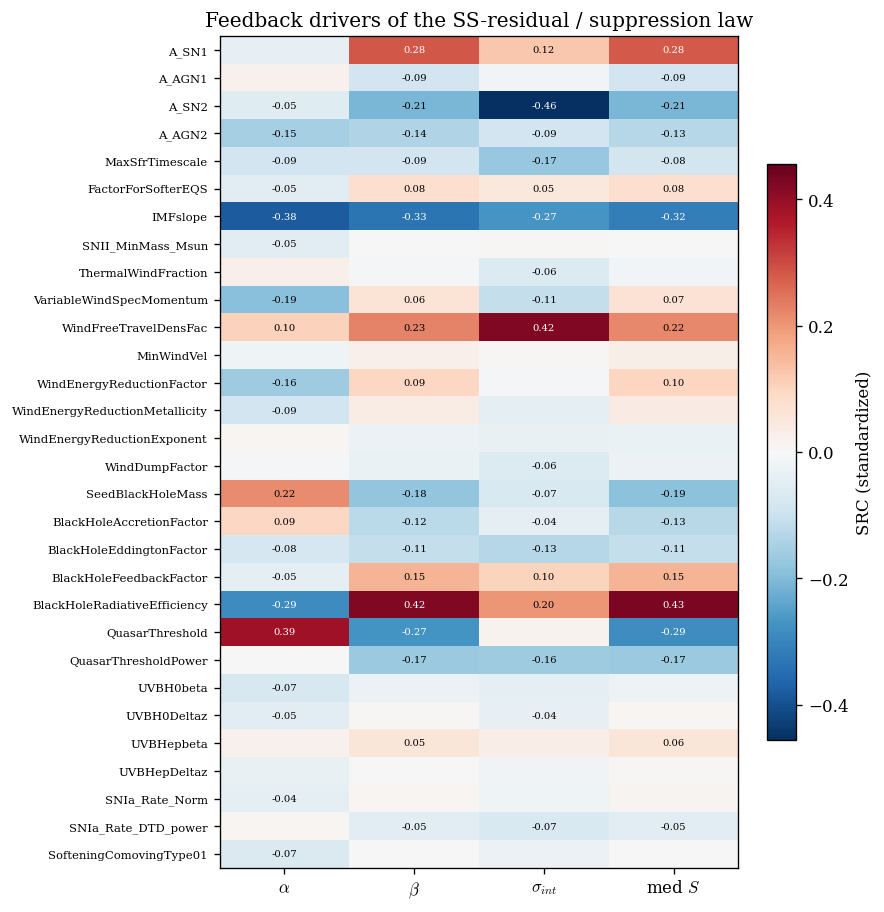

In [5]:
vmax = np.nanmax(np.abs(SRC))
fig, ax = plt.subplots(figsize=(6.2, 9))
im = ax.imshow(SRC, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(TARGETS)))
ax.set_xticklabels([r'$\alpha$', r'$\beta$', r'$\sigma_{int}$', 'med $S$'])
ax.set_yticks(range(len(PLAB))); ax.set_yticklabels(PLAB, fontsize=7)
for i in range(len(PLAB)):
    for j in range(len(TARGETS)):
        if (SRC_lo[i, j] > 0) or (SRC_hi[i, j] < 0):
            ax.text(j, i, '%.2f' % SRC[i, j], ha='center', va='center', fontsize=6,
                    color='w' if abs(SRC[i, j]) > 0.5 * vmax else 'k')
fig.colorbar(im, ax=ax, fraction=0.05, label='SRC (standardized)')
ax.set_title('Feedback drivers of the SS-residual / suppression law')
savefig(fig, 'ss_src_heatmap'); plt.show()

wrote tsz_ss_sobol_figs/ss_top_drivers.png


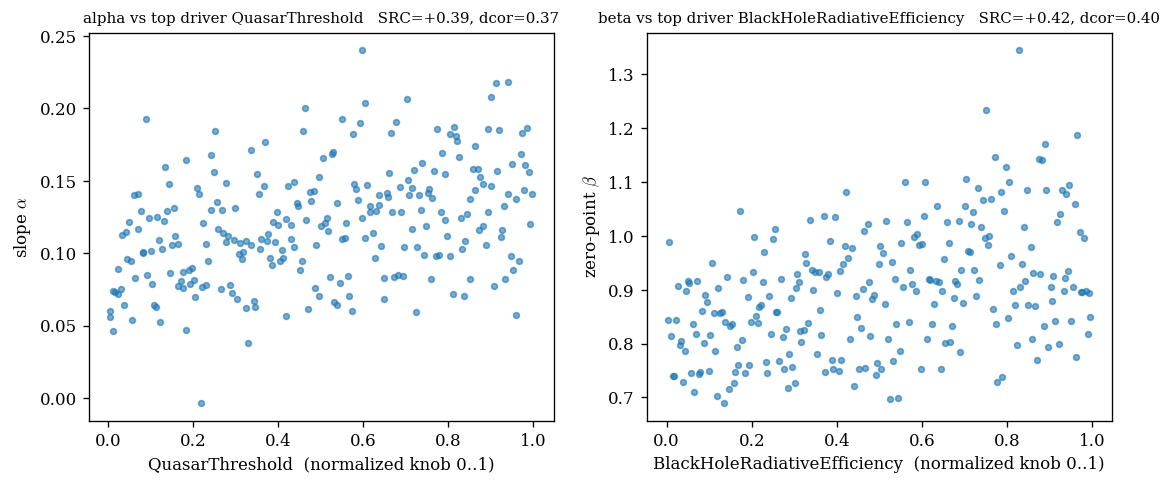

In [7]:
def top_driver(t):
    j = TARGETS.index(t)
    return int(np.nanargmax(np.abs(SRC[:, j])))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, t in zip(axes, ['alpha', 'beta']):
    i = top_driver(t); j = TARGETS.index(t)
    ax.scatter(design_norm[:, i], fit_df[t].values, s=12, c='tab:blue', alpha=0.6)
    ax.set_xlabel(f'{PLAB[i]}  (normalized knob 0..1)')
    ax.set_ylabel({'alpha': r'slope $\alpha$', 'beta': r'zero-point $\beta$'}[t])
    ax.set_title(f'{t} vs top driver {PLAB[i]}   '
                 f'SRC={SRC[i, j]:+.2f}, dcor={dcor(design_norm[:, i], fit_df[t].values):.2f}',
                 fontsize=9)
savefig(fig, 'ss_top_drivers'); plt.show()

## 4. Scorecard

In [8]:
print('=' * 72)
print('SENSITIVITY SCORECARD - drivers of the SS-residual -> suppression law')
print('=' * 72)
for j, t in enumerate(TARGETS):
    print(f'\n[{t}]   linear R2 = {R2[t]:.3f}')
    rank = np.argsort(-np.abs(SRC[:, j]))[:5]
    for i in rank:
        dc = dcor(design_norm[:, i], fit_df[t].values)
        sig = '*' if (SRC_lo[i, j] > 0 or SRC_hi[i, j] < 0) else ' '
        print(f'  {sig} {PLAB[i]:26s} SRC={SRC[i, j]:+.3f} '
              f'[{SRC_lo[i, j]:+.3f}, {SRC_hi[i, j]:+.3f}]   dcor={dc:.3f}')

SENSITIVITY SCORECARD - drivers of the SS-residual -> suppression law

[alpha]   linear R2 = 0.557
  * QuasarThreshold            SRC=+0.387 [+0.350, +0.435]   dcor=0.366
  * IMFslope                   SRC=-0.378 [-0.422, -0.333]   dcor=0.351
  * BlackHoleRadiativeEfficiency SRC=-0.287 [-0.327, -0.239]   dcor=0.294
  * SeedBlackHoleMass          SRC=+0.216 [+0.173, +0.259]   dcor=0.209
  * VariableWindSpecMomentum   SRC=-0.193 [-0.239, -0.149]   dcor=0.195

[beta]   linear R2 = 0.697
  * BlackHoleRadiativeEfficiency SRC=+0.421 [+0.386, +0.457]   dcor=0.403
  * IMFslope                   SRC=-0.335 [-0.378, -0.292]   dcor=0.396
  * A_SN1                      SRC=+0.283 [+0.245, +0.323]   dcor=0.279
  * QuasarThreshold            SRC=-0.273 [-0.316, -0.233]   dcor=0.284
  * WindFreeTravelDensFac      SRC=+0.227 [+0.190, +0.269]   dcor=0.250

[sigma_int]   linear R2 = 0.644
  * A_SN2                      SRC=-0.457 [-0.493, -0.419]   dcor=0.476
  * WindFreeTravelDensFac      SRC=+0.424 [+

## 5. Alternative visual lenses

The same Sobol cube can be viewed from three complementary perspectives:

1. A **phase diagram** in calibration-parameter space ($\alpha$ vs $\beta$), colored by intrinsic scatter $\sigma_{\rm int}$.
2. **Tornado plots** showing the strongest signed drivers for each target with bootstrap uncertainty bars.
3. A **PCA map** of the 30-D feedback cube to reveal large-scale gradients in fitted calibration parameters.

These answer different questions:
- Where do design points live globally? (phase diagram)
- Which knobs matter most, and with what sign? (tornado)
- Are responses smooth or fragmented in parameter space? (PCA landscape)

wrote tsz_ss_sobol_figs/ss_phase_diagram.png


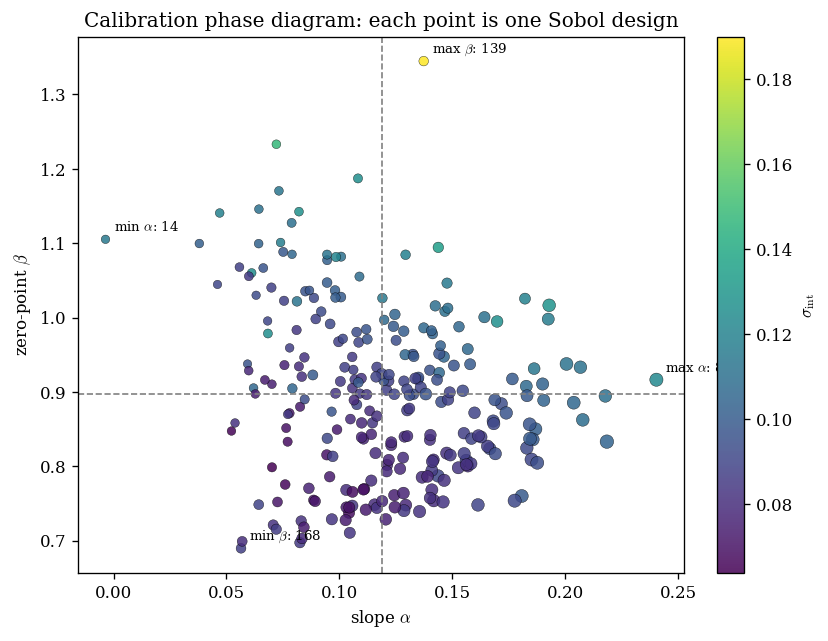

In [9]:
# 5a) Global phase diagram of design-level calibration behavior
alpha = fit_df['alpha'].values.astype(float)
beta = fit_df['beta'].values.astype(float)
sig = fit_df['sigma_int'].values.astype(float)
rho = fit_df['spearman'].values.astype(float)

m = np.isfinite(alpha) & np.isfinite(beta) & np.isfinite(sig) & np.isfinite(rho)
a, b, s, r = alpha[m], beta[m], sig[m], rho[m]

sizes = 25 + 140 * np.clip(np.abs(r), 0, 1) ** 1.5
fig, ax = plt.subplots(figsize=(7.2, 5.8))
sc = ax.scatter(a, b, c=s, s=sizes, cmap='viridis', alpha=0.85, edgecolor='k', linewidth=0.25)

ax.axvline(np.nanmedian(a), color='0.5', lw=1, ls='--')
ax.axhline(np.nanmedian(b), color='0.5', lw=1, ls='--')
ax.set_xlabel(r'slope $\alpha$')
ax.set_ylabel(r'zero-point $\beta$')
ax.set_title(r'Calibration phase diagram: each point is one Sobol design')
fig.colorbar(sc, ax=ax, fraction=0.045, label=r'$\sigma_{\rm int}$')

# Annotate extreme designs for quick orientation.
i_min_a = int(np.nanargmin(alpha))
i_max_a = int(np.nanargmax(alpha))
i_min_b = int(np.nanargmin(beta))
i_max_b = int(np.nanargmax(beta))
for name, d in [('min $\\alpha$', i_min_a), ('max $\\alpha$', i_max_a),
                ('min $\\beta$', i_min_b), ('max $\\beta$', i_max_b)]:
    ax.annotate(f'{name}: {d}', (alpha[d], beta[d]), xytext=(5, 5),
                textcoords='offset points', fontsize=8)

savefig(fig, 'ss_phase_diagram'); plt.show()

wrote tsz_ss_sobol_figs/ss_tornado_drivers.png


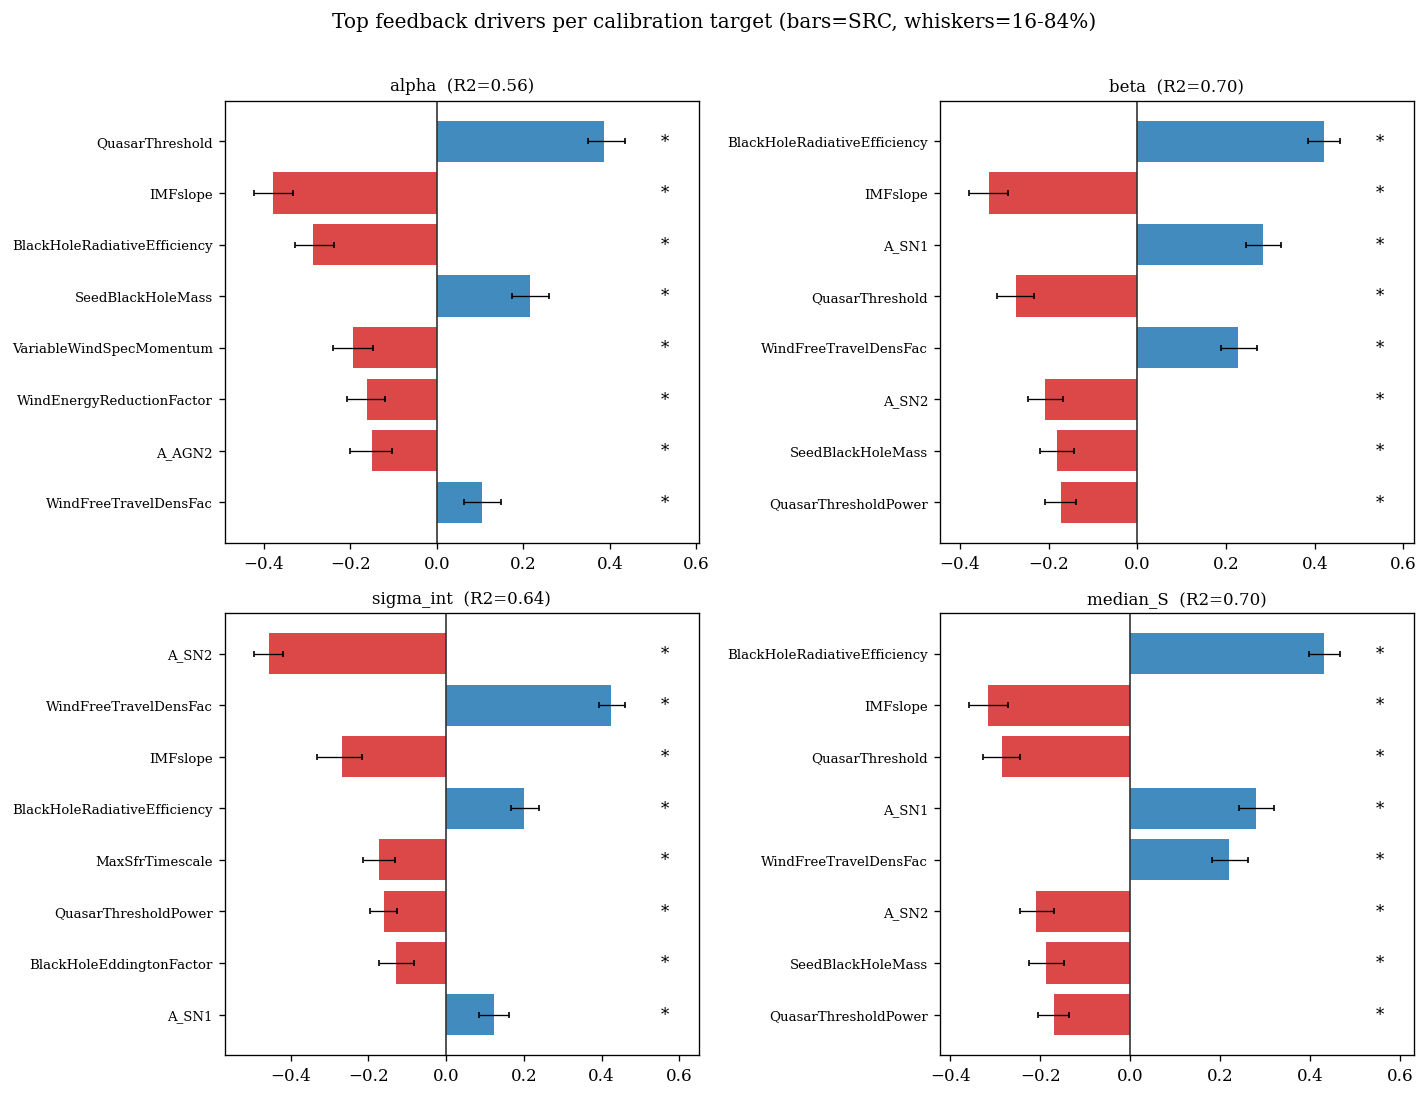

In [10]:
# 5b) Tornado-style sensitivity summaries (top signed drivers per target)
def tornado_one(ax, target, topn=8):
    j = TARGETS.index(target)
    valid = np.isfinite(SRC[:, j]) & np.isfinite(SRC_lo[:, j]) & np.isfinite(SRC_hi[:, j])
    idx = np.where(valid)[0]
    rank = idx[np.argsort(-np.abs(SRC[idx, j]))[:topn]]

    vals = SRC[rank, j]
    lo = SRC_lo[rank, j]
    hi = SRC_hi[rank, j]
    names = [PLAB[i] for i in rank]
    y = np.arange(len(rank))

    colors = np.where(vals >= 0, '#1f77b4', '#d62728')
    ax.barh(y, vals, color=colors, alpha=0.85)
    xerr = np.vstack([vals - lo, hi - vals])
    ax.errorbar(vals, y, xerr=xerr, fmt='none', ecolor='k', elinewidth=0.8, capsize=2)
    ax.axvline(0, color='0.2', lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'{target}  (R2={R2[target]:.2f})', fontsize=10)

    xmin = float(np.nanmin(lo))
    xmax = float(np.nanmax(hi))
    pad = 0.08 * (xmax - xmin + 1e-12)
    ax.set_xlim(xmin - pad, xmax + 2.5 * pad)

    sig_mask = (lo > 0) | (hi < 0)
    x_star = xmax + 1.2 * pad
    for yy, is_sig in zip(y, sig_mask):
        if is_sig:
            ax.text(x_star, yy, '*', va='center', ha='left', fontsize=10)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
for ax, t in zip(axes.ravel(), TARGETS):
    tornado_one(ax, t, topn=8)
fig.suptitle('Top feedback drivers per calibration target (bars=SRC, whiskers=16-84%)', y=1.01)
fig.tight_layout()
savefig(fig, 'ss_tornado_drivers'); plt.show()

wrote tsz_ss_sobol_figs/ss_pca_landscape.png


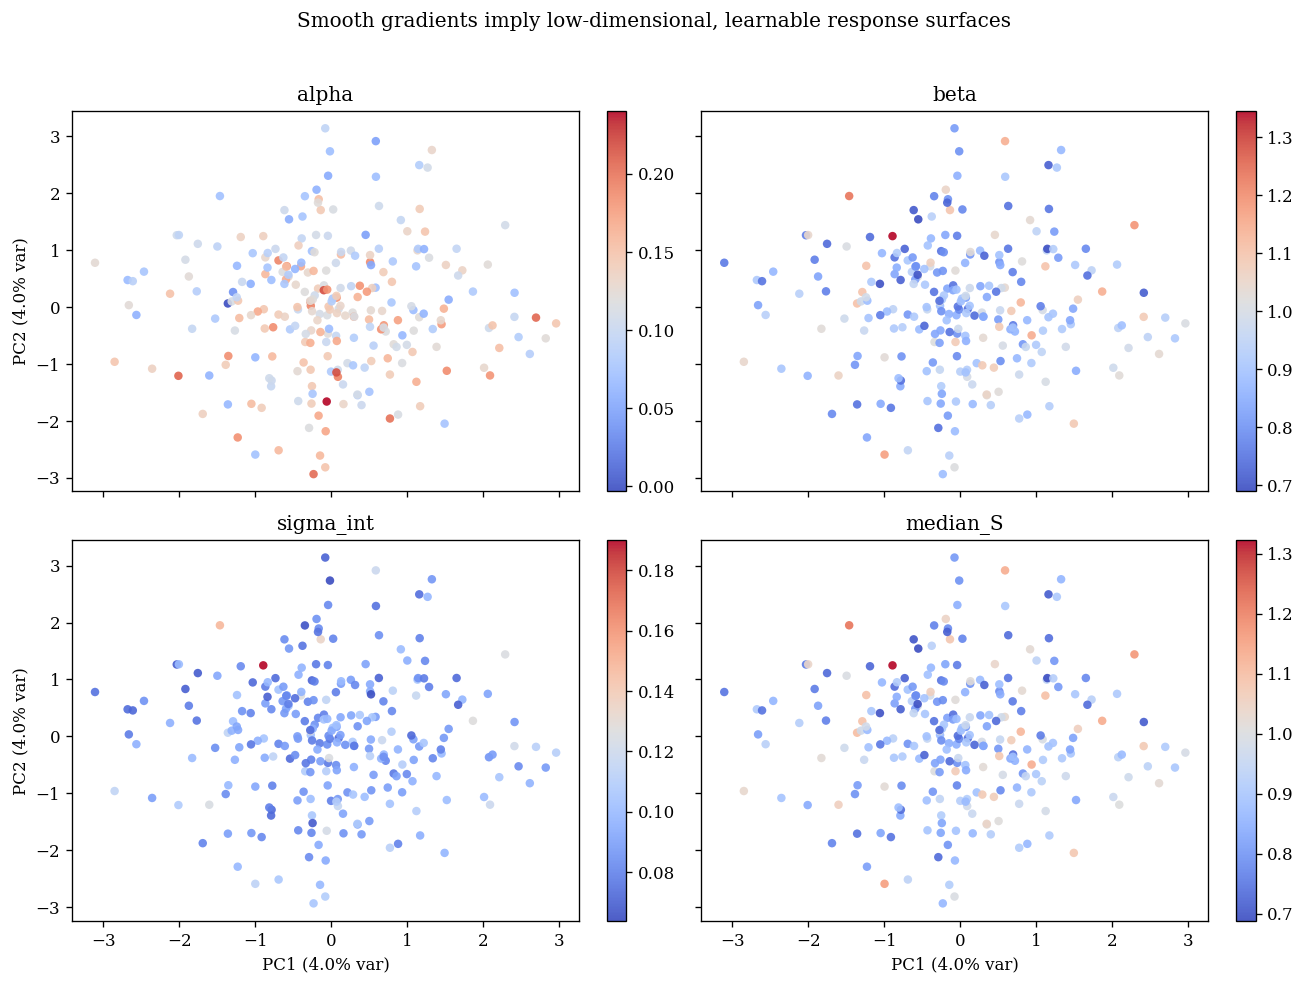

In [11]:
# 5c) PCA map of 30-D feedback space colored by calibration outputs
X = np.asarray(design_norm, float)
Xm = np.nanmean(X, axis=0, keepdims=True)
Xs = np.nanstd(X, axis=0, keepdims=True) + 1e-12
Xz = np.nan_to_num((X - Xm) / Xs, nan=0.0)

U, Svals, Vt = np.linalg.svd(Xz, full_matrices=False)
PC = Xz @ Vt[:2].T
var = (Svals ** 2) / np.sum(Svals ** 2)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, t in zip(axes.ravel(), TARGETS):
    c = fit_df[t].values.astype(float)
    sc = ax.scatter(PC[:, 0], PC[:, 1], c=c, cmap='coolwarm', s=26, alpha=0.9, edgecolor='none')
    ax.set_title(t)
    fig.colorbar(sc, ax=ax, fraction=0.046)

axes[1, 0].set_xlabel(f'PC1 ({100 * var[0]:.1f}% var)')
axes[1, 1].set_xlabel(f'PC1 ({100 * var[0]:.1f}% var)')
axes[0, 0].set_ylabel(f'PC2 ({100 * var[1]:.1f}% var)')
axes[1, 0].set_ylabel(f'PC2 ({100 * var[1]:.1f}% var)')
fig.suptitle('Smooth gradients imply low-dimensional, learnable response surfaces', y=1.02)
fig.tight_layout()
savefig(fig, 'ss_pca_landscape'); plt.show()

## 6. What is the point of this notebook?

This notebook is not just fitting lines; it tests whether a physically motivated **one-number halo summary**,
$\Delta_{\rm SS}$, remains predictive for matter suppression across feedback space.

Core purpose:
1. **Compression:** Reduce complex baryonic effects to a low-dimensional calibration law $(\alpha,\beta,\sigma_{\rm int})$.
2. **Control knobs:** Identify which feedback parameters tilt the law (change $\alpha$), shift it (change $\beta$), or add stochasticity ($\sigma_{\rm int}$).
3. **Transferability check:** Determine whether a measured tSZ residual can forecast small-scale suppression away from one fiducial model.
4. **Practical outcome:** Build interpretable priors for baryonic uncertainty in weak-lensing and clustering analyses.

Interpretation guide:
- Smooth maps with a few dominant drivers mean the calibration is actionable.
- Fragmented maps or large $\sigma_{\rm int}$ mean $\Delta_{\rm SS}$ is a weaker transport statistic.

In [12]:
# 6a) Quick numerical takeaway table
rows = []
for t in TARGETS:
    j = TARGETS.index(t)
    y = fit_df[t].values.astype(float)
    sig_frac = np.mean((SRC_lo[:, j] > 0) | (SRC_hi[:, j] < 0))
    rows.append({
        'target': t,
        'median': float(np.nanmedian(y)),
        'p16': float(np.nanpercentile(y, 16)),
        'p84': float(np.nanpercentile(y, 84)),
        'linear_R2': float(R2[t]),
        'significant_driver_fraction': float(sig_frac),
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

,target,median,p16,p84,linear_R2,significant_driver_fraction
0,alpha,0.118804,0.078646,0.157884,0.557494,0.666667
1,beta,0.896586,0.770126,1.015823,0.697476,0.633333
2,sigma_int,0.089159,0.078018,0.105679,0.644256,0.600000
3,median_S,0.881887,0.764558,0.999857,0.695616,0.633333


## 6.5 Why is the per-halo law weak? — conditioning on the halo's own gas content

The money plot's per-halo slope is weak (median Spearman $\rho\simeq0.24$). Before pivoting to
population observables in §7, we diagnose *why* at the per-halo level, importing the central
idea of the BIND **scatter** analysis (`analysis/2d`): a halo's deviation from a mean relation
is set by other *measurable* halo properties, and a residual is only as predictive as the
mechanism it traces. The Sobol cube stores each halo's gas fraction $f_{\rm gas}$ and thermo
scalars (mass-weighted $T$, entropy $S$, pressure $P$) alongside $\Delta_{\rm SS}$, so we ask,
per design and per halo:

1. **Which scalar best predicts a halo's own suppression** — $\Delta_{\rm SS}$, or a direct gas
   observable?
2. **Does $\Delta_{\rm SS}$ carry information beyond the halo's gas content?** — i.e. the partial
   Spearman $\rho(\Delta_{\rm SS},S\,|\,f_{\rm gas})$ vs $\rho(f_{\rm gas},S\,|\,\Delta_{\rm SS})$.

We score against both suppression metrics: the Fourier ratio at $k\approx10.4$ (the $P(k)$
analog, noisy per patch) and the configuration-space profile ratio over $0.1$–$0.5\,R_{200}$
(tighter).

wrote tsz_ss_sobol_figs/ss_perhalo_predictors.png


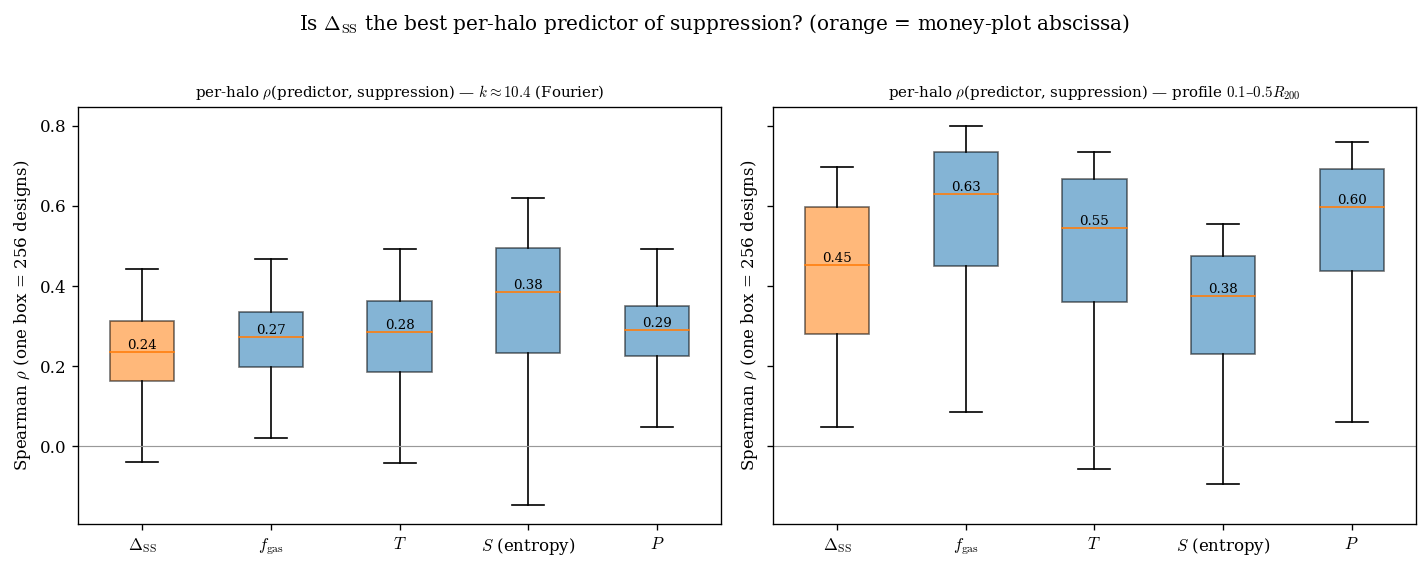

Per-halo predictor ranking (median Spearman rho across 256 designs):
  vs supp_k10  : $S$ (entropy)=+0.385  $P$=+0.291  $T$=+0.285  $f_{\rm gas}$=+0.272  $\Delta_{\rm SS}$=+0.236
  vs supp_prof : $f_{\rm gas}$=+0.630  $P$=+0.597  $T$=+0.546  $\Delta_{\rm SS}$=+0.453  $S$ (entropy)=+0.375

Partial correlations vs supp_k10 (do they add info beyond each other?):
  rho(Delta_SS, supp | f_gas)   median = +0.097   (marginal Delta_SS was +0.236)
  rho(f_gas,    supp | Delta_SS) median = +0.153   (marginal f_gas was +0.272)


In [13]:
# 6.5 Per-halo predictor comparison + partial correlations (per design, then summarised)
from scipy.stats import rankdata

iFG = OBS_NAMES.index('f_gas')

def _rank(v):
    v = np.asarray(v, float); r = np.full_like(v, np.nan)
    m = np.isfinite(v); r[m] = rankdata(v[m]); return r

def partial_spearman(a, b, c):
    """Spearman partial rho(a,b | c): rank, linear-regress out ranked c, correlate residuals."""
    a, b, c = _rank(a), _rank(b), _rank(c)
    m = np.isfinite(a) & np.isfinite(b) & np.isfinite(c)
    a, b, c = a[m], b[m], c[m]
    if m.sum() < 10:
        return np.nan
    C = np.c_[np.ones(len(c)), c]
    ra = a - C @ np.linalg.lstsq(C, a, rcond=None)[0]
    rb = b - C @ np.linalg.lstsq(C, b, rcond=None)[0]
    sa, sb = ra.std(), rb.std()
    return float((ra * rb).mean() / (sa * sb)) if sa > 0 and sb > 0 else np.nan

# candidate per-halo predictors of suppression: Delta_SS (the money-plot abscissa) + gas obs
PRED = {r'$\Delta_{\rm SS}$': None, r'$f_{\rm gas}$': iFG, '$T$': OBS_NAMES.index('T'),
        '$S$ (entropy)': OBS_NAMES.index('S'), '$P$': OBS_NAMES.index('P')}
SUPP_METRICS = [('supp_k10', r'$k\approx10.4$ (Fourier)'),
                ('supp_prof', r'profile $0.1$–$0.5R_{200}$')]

rho = {sm: {k: [] for k in PRED} for sm, _ in SUPP_METRICS}
part_dss_fg, part_fg_dss = [], []   # partials vs supp_k10 (the money-plot metric)
for d in range(n_design):
    xdev, _, _ = _design_arrays(d)
    fg = OBS[d, :, iFG]
    for sm, _ in SUPP_METRICS:
        Supp = OBS[d, :, OBS_NAMES.index(sm)]
        for k, ci in PRED.items():
            pv = xdev if ci is None else OBS[d, :, ci]
            m = np.isfinite(pv) & np.isfinite(Supp)
            if m.sum() >= 10:
                rho[sm][k].append(spearmanr(pv[m], Supp[m]).correlation)
    Sk = OBS[d, :, OBS_NAMES.index('supp_k10')]
    part_dss_fg.append(partial_spearman(xdev, Sk, fg))
    part_fg_dss.append(partial_spearman(fg, Sk, xdev))

# ---- figure: per-design distribution of per-halo rho for each predictor ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
labels = list(PRED.keys())
for ax, (sm, smlab) in zip(axes, SUPP_METRICS):
    data = [np.array(rho[sm][k]) for k in labels]
    bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor('tab:orange' if labels[i].startswith(r'$\Delta') else 'tab:blue')
        patch.set_alpha(0.55)
    meds = [np.nanmedian(np.array(rho[sm][k])) for k in labels]
    for i, mv in enumerate(meds):
        ax.text(i + 1, mv, f'{mv:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(0, color='0.6', lw=0.7)
    ax.set_title(f'per-halo $\\rho$(predictor, suppression) — {smlab}', fontsize=9)
    ax.set_ylabel(r'Spearman $\rho$ (one box = 256 designs)')
fig.suptitle('Is $\\Delta_{\\rm SS}$ the best per-halo predictor of suppression? (orange = money-plot abscissa)', y=1.02)
fig.tight_layout()
savefig(fig, 'ss_perhalo_predictors'); plt.show()

print('Per-halo predictor ranking (median Spearman rho across 256 designs):')
for sm, smlab in SUPP_METRICS:
    order = sorted(PRED, key=lambda k: -np.nanmedian(rho[sm][k]))
    s = '  '.join(f'{k}={np.nanmedian(rho[sm][k]):+.3f}' for k in order)
    print(f'  vs {sm:10s}: {s}')
print('\nPartial correlations vs supp_k10 (do they add info beyond each other?):')
print(f'  rho(Delta_SS, supp | f_gas)   median = {np.nanmedian(part_dss_fg):+.3f}'
      f'   (marginal Delta_SS was {np.nanmedian(rho["supp_k10"][labels[0]]):+.3f})')
print(f'  rho(f_gas,    supp | Delta_SS) median = {np.nanmedian(part_fg_dss):+.3f}'
      f'   (marginal f_gas was {np.nanmedian(rho["supp_k10"][labels[1]]):+.3f})')


**What this shows.** $\Delta_{\rm SS}$ is *not* the most predictive per-halo scalar. Against the
noisy Fourier metric the thermo scalars edge it out (entropy $S\simeq0.39$ vs
$\Delta_{\rm SS}\simeq0.24$); against the tighter profile metric the halo's **gas fraction is the
clear winner** ($f_{\rm gas}\simeq0.63$ vs $\Delta_{\rm SS}\simeq0.45$). The partial
correlations are the punchline: conditioning on $f_{\rm gas}$ collapses
$\rho(\Delta_{\rm SS},S)$ from $\simeq0.24$ to $\simeq0.10$, whereas $f_{\rm gas}$ retains
independent power ($\rho\simeq0.15$) after removing $\Delta_{\rm SS}$. So the weak money-plot
slope is largely a *noisy shadow of gas content*: $\Delta_{\rm SS}$ and suppression are both
downstream of how much gas the halo has lost, and $\Delta_{\rm SS}$ traces that more weakly than
$f_{\rm gas}$ does.

This is the same lesson the scatter analysis reached for mass–mass relations — residuals are
proxies for an underlying physical driver — and it gives §7's pivot a mechanism rather than an
assertion: gas content is the more fundamental suppression predictor, at the per-halo level
here and at the population level next.

## 6.6 Is it structure-inherited? — testing the scatter paper's "master predictor"

§6.5 showed gas content, not $\Delta_{\rm SS}$, is the better per-halo predictor. But *where does
that scatter come from?* The BIND **scatter** analysis (`analysis/2d`) found that for mass–mass
scaling relations the dominant driver of a halo's residual is its **structure** — DMO
concentration was "the master predictor (strongest $|\rho|$ across most relations)", and much of
it is *inherited* from the DMO field BIND conditions on. We test that hypothesis directly here.

Using `extract_dmo_structure.py`, we compute four design-independent structural features of each
halo's **fixed DMO input map** — central concentration `c_core`, half-mass radius `r_half`, and
projected axis ratios `q_DMO` / `q_DMO_in` — aligned 1:1 with the cube. Then we ask: do they
predict a halo's suppression, and does conditioning the money plot on DMO concentration weaken
it? If the scatter-paper picture transfers, structure should carry the signal.

wrote tsz_ss_sobol_figs/ss_dmo_structure.png


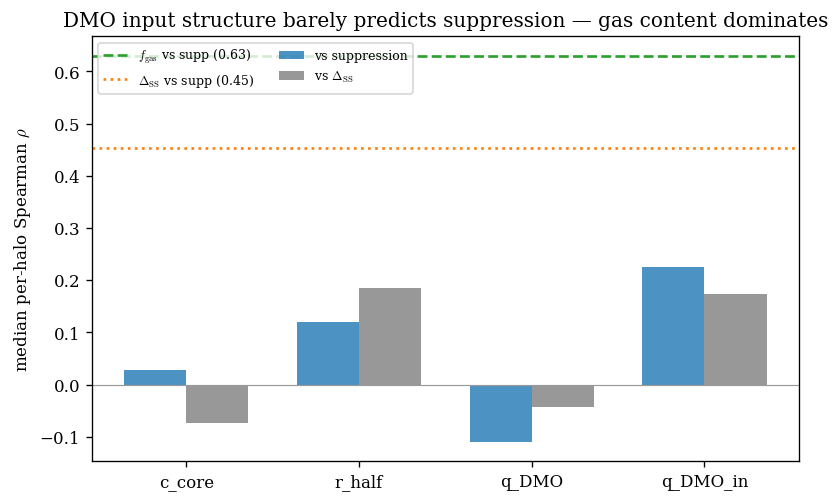

DMO structural feature -> median per-halo rho (vs supp_prof, vs Delta_SS):
  c_core    supp=+0.027   dss=-0.074
  r_half    supp=+0.119   dss=+0.184
  q_DMO     supp=-0.110   dss=-0.044
  q_DMO_in  supp=+0.226   dss=+0.174

  reference (§6.5):  f_gas vs supp = +0.630    Delta_SS vs supp = +0.453
  partial rho(Delta_SS, supp | c_core) = +0.460  (marginal Delta_SS = +0.453 -> conditioning on DMO concentration changes nothing)
  rho(c_core, f_gas) = +0.017  (DMO concentration is orthogonal to gas content)


In [14]:
# 6.6 DMO-structure conditioning: does the halo's input morphology drive suppression?
DS = np.load(CUBE.parent / 'dmo_structure.npz', allow_pickle=True)
assert np.nanmax(np.abs(DS['M200'] - z['M200'])) == 0, 'dmo_structure rows must match the cube'
SF = DS['feats']; SF_NAMES = list(DS['feat_names'])      # (n_halo, 4) design-independent

iSp = OBS_NAMES.index('supp_prof')
# per-design per-halo Spearman of each DMO feature vs suppression and vs Delta_SS
rho_struct = {f: {'supp': [], 'dss': []} for f in SF_NAMES}
part_dss_ccore = []                                       # rho(Delta_SS, supp | c_core)
ic = SF_NAMES.index('c_core')
for d in range(n_design):
    xdev, _, _ = _design_arrays(d)
    Sp = OBS[d, :, iSp]
    for j, f in enumerate(SF_NAMES):
        rho_struct[f]['supp'].append(spearmanr(SF[:, j], Sp, nan_policy='omit').correlation)
        rho_struct[f]['dss'].append(spearmanr(SF[:, j], xdev, nan_policy='omit').correlation)
    part_dss_ccore.append(partial_spearman(xdev, Sp, SF[:, ic]))

# reference medians from §6.5 (per-halo rho vs supp_prof) — gas content vs Delta_SS
ref_fgas = np.nanmedian(rho['supp_prof'][r'$f_{\rm gas}$'])
ref_dss = np.nanmedian(rho['supp_prof'][r'$\Delta_{\rm SS}$'])
# DMO concentration is essentially orthogonal to gas content:
rho_c_fg = np.nanmedian([spearmanr(SF[:, ic], OBS[d, :, iFG], nan_policy='omit').correlation
                         for d in range(n_design)])

fig, ax = plt.subplots(figsize=(7.6, 4.6))
xpos = np.arange(len(SF_NAMES))
med_supp = [np.nanmedian(rho_struct[f]['supp']) for f in SF_NAMES]
med_dss = [np.nanmedian(rho_struct[f]['dss']) for f in SF_NAMES]
ax.bar(xpos - 0.18, med_supp, 0.36, label=r'vs suppression', color='tab:blue', alpha=0.8)
ax.bar(xpos + 0.18, med_dss, 0.36, label=r'vs $\Delta_{\rm SS}$', color='tab:grey', alpha=0.8)
ax.axhline(ref_fgas, color='tab:green', lw=1.6, ls='--', label=rf'$f_{{\rm gas}}$ vs supp ({ref_fgas:.2f})')
ax.axhline(ref_dss, color='tab:orange', lw=1.6, ls=':', label=rf'$\Delta_{{\rm SS}}$ vs supp ({ref_dss:.2f})')
ax.axhline(0, color='0.6', lw=0.7)
ax.set_xticks(xpos); ax.set_xticklabels(SF_NAMES)
ax.set_ylabel(r'median per-halo Spearman $\rho$')
ax.set_title('DMO input structure barely predicts suppression — gas content dominates')
ax.legend(fontsize=7.5, ncol=2, loc='upper left')
savefig(fig, 'ss_dmo_structure'); plt.show()

print('DMO structural feature -> median per-halo rho (vs supp_prof, vs Delta_SS):')
for f in SF_NAMES:
    print(f'  {f:9s} supp={np.nanmedian(rho_struct[f]["supp"]):+.3f}   dss={np.nanmedian(rho_struct[f]["dss"]):+.3f}')
print(f'\n  reference (§6.5):  f_gas vs supp = {ref_fgas:+.3f}    Delta_SS vs supp = {ref_dss:+.3f}')
print(f'  partial rho(Delta_SS, supp | c_core) = {np.nanmedian(part_dss_ccore):+.3f}'
      f'  (marginal Delta_SS = {ref_dss:+.3f} -> conditioning on DMO concentration changes nothing)')
print(f'  rho(c_core, f_gas) = {rho_c_fg:+.3f}  (DMO concentration is orthogonal to gas content)')


**The scatter-paper master predictor does *not* transfer.** Every DMO structural feature is a
weak predictor of suppression — central concentration `c_core` ($\rho\simeq0.03$), `q_DMO`
($\rho\simeq-0.11$), `r_half` ($\rho\simeq0.12$), inner shape `q_DMO_in` ($\rho\simeq0.23$, the
strongest) — all far below the gas fraction ($\rho\simeq0.63$) and even $\Delta_{\rm SS}$
($\rho\simeq0.45$). Conditioning the money plot on DMO concentration leaves it essentially
unchanged ($\rho(\Delta_{\rm SS},S\,|\,c_{\rm core})\simeq0.46$ vs marginal $0.45$), and
$c_{\rm core}$ is orthogonal to gas content ($\rho\simeq0.02$).

**Interpretation — two distinct scatter regimes.** In the scatter paper, mass–mass relation
scatter is *structural*: it is largely inherited from the DMO field's concentration/shape, so
BIND can reproduce it by reading the input morphology. Thermodynamic suppression is the
opposite: it is set by **how much gas the halo's feedback history expelled**, which is *not*
encoded in the DMO input and is nearly independent of halo structure. This is why §6.5's
$f_{\rm gas}$ wins and DMO structure loses here — and it explains, at the mechanism level, why
the suppression prior in §7 must be conditioned on a *baryonic* observable ($f_{\rm gas}$, the
$Y$–$M$ amplitude) rather than on anything inheritable from the dark matter. The two notebooks
therefore map a clean dividing line: **structure-driven scatter (mass relations) vs
feedback-driven scatter (thermodynamics/suppression).**

## 7. From a per-halo law to an observable-conditioned suppression prior

Sections 1–4 fit the **per-halo** money plot inside each feedback model: how well one halo's
self-similar residual $\Delta_{\rm SS}$ predicts *its own* suppression. That slope is weak
(median Spearman $\rho\simeq0.24$) — and §6.5–6.6 traced *why*: $\Delta_{\rm SS}$ is a noisy
proxy for the halo's gas content, which is feedback- rather than structure-driven, so a direct
gas observable predicts suppression better and DMO morphology barely at all. It is also **not
the quantity a survey measures.** Matter-power suppression is a population statistic, and what
tSZ / X-ray surveys actually constrain is a *population mean*: the stacked $Y$–$M$ amplitude, or
the mean group gas fraction $f_{\rm gas}$.

So here we change the question. For each Sobol design we collapse the 1111 halos to the
**population observables** a survey could measure, and ask whether *those* predict the design's
mean suppression. The motivating context: baryonic feedback suppresses $P(k)$ by $\sim$10–30%
at $k\sim1$–$10\,h/$Mpc — the dominant astrophysical systematic for Stage-IV weak lensing
(Rubin/LSST, Euclid, Roman). If a measurable thermodynamic observable forecasts that
suppression, the deliverable is an **observable-conditioned prior**: measure $f_{\rm gas}$ (or
the $Y$–$M$ amplitude) $\Rightarrow$ forecast $P_{\rm hydro}/P_{\rm DMO}$ with a calibrated
uncertainty, replacing an uninformative marginalization over feedback.

In [15]:
# 7.0 Collapse each design's 1111 halos to the population observables a survey measures
iFG = OBS_NAMES.index('f_gas'); iSp = OBS_NAMES.index('supp_prof')

logc0_d = np.full(n_design, np.nan)   # Y-M amplitude (self-similar normalization)
fgas_d  = np.full(n_design, np.nan)   # median halo gas fraction (<R200)
supp_d  = np.full(n_design, np.nan)   # median P_hydro/P_DMO at k~10.4 (Fourier)
suppP_d = np.full(n_design, np.nan)   # median profile-ratio suppression (0.1-0.5 R200)
for d in range(n_design):
    Y = OBS[d, :, iY]
    base = np.isfinite(logM) & np.isfinite(Y) & (Y > 0)
    logc0_d[d] = np.mean(np.log10(Y[base]) - (5 / 3) * logM[base])
    fgas_d[d]  = np.nanmedian(OBS[d, :, iFG])
    supp_d[d]  = np.nanmedian(OBS[d, :, iS])
    suppP_d[d] = np.nanmedian(OBS[d, :, iSp])
dY = logc0_d - np.median(logc0_d)     # Y-M amplitude relative to the design median

print(f'Population spread across {n_design} designs:')
print(f'  Y-M amplitude  d_logc0  range [{dY.min():+.3f}, {dY.max():+.3f}]')
print(f'  median f_gas            range [{fgas_d.min():.3f}, {fgas_d.max():.3f}]')
print(f'  median supp (k~10.4)    range [{supp_d.min():.3f}, {supp_d.max():.3f}]')
print(f'  median supp (profile)   range [{suppP_d.min():.3f}, {suppP_d.max():.3f}]')
print('\nPopulation predictiveness (Spearman across designs) -- cf. per-halo rho~0.24:')
for slab, s in [('supp k~10.4', supp_d), ('supp profile', suppP_d)]:
    print(f'  {slab:13s} vs f_gas: {spearmanr(fgas_d, s).correlation:+.3f}'
          f'   vs Y-M amp: {spearmanr(dY, s).correlation:+.3f}')

Population spread across 256 designs:
  Y-M amplitude  d_logc0  range [-0.468, +0.086]
  median f_gas            range [0.060, 0.161]
  median supp (k~10.4)    range [0.688, 1.322]
  median supp (profile)   range [0.885, 1.036]

Population predictiveness (Spearman across designs) -- cf. per-halo rho~0.24:
  supp k~10.4   vs f_gas: +0.516   vs Y-M amp: +0.533
  supp profile  vs f_gas: +0.814   vs Y-M amp: +0.845


### 7.1 The population calibration

Across the 256 designs the median suppression tracks both the population gas fraction and the
$Y$–$M$ amplitude with Spearman $\rho\simeq0.5$ (Fourier $k\approx10.4$) to $\rho\simeq0.85$
(profile ratio) — i.e. the *population* observable is **3–4$\times$ more predictive** than the
per-halo $\Delta_{\rm SS}$ slope ($\rho\simeq0.24$). The two suppression metrics — the Fourier
ratio at $k\approx10.4$ (the $P(k)$ analog, noisier on a single 6.25 Mpc/h patch) and the
configuration-space profile ratio over $0.1$–$0.5\,R_{200}$ (tighter) — tell the same story.
The red band is the $\pm1\sigma_{\rm pred}$ prior (MLE fit with intrinsic scatter); dashed lines
mark the van Daalen+20 TNG/EAGLE/BAHAMAS values at $k=10$.

wrote tsz_ss_sobol_figs/ss_population_prior.png


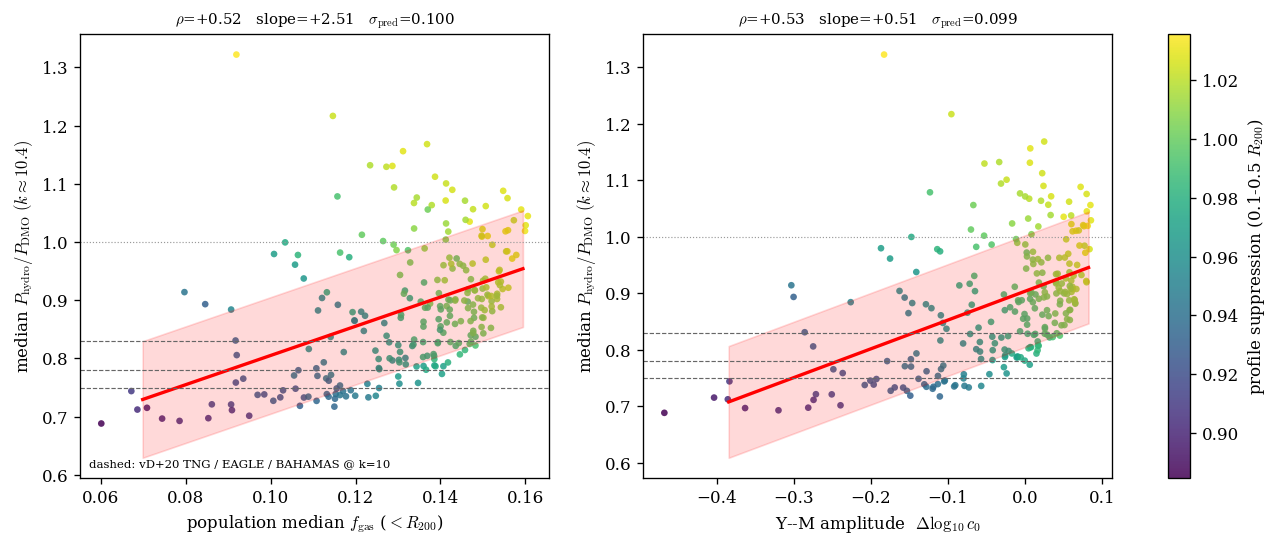

In [ ]:
# 7.1 Population calibration: mean suppression vs observable, with a prior band.
# Styled to mirror the tsz_wl_calibration money-plot panels: clean two-panel layout,
# scatter + linear fit on bin-medians + sigma_pred band, info text box, suptitle.

def fit_prior(x, y):
    """MLE line y = a*x + b with intrinsic (prediction) scatter sigma."""
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    def nll(th):
        a, b, ls = th; s2 = np.exp(2 * ls); r = y - (a * x + b)
        return 0.5 * np.sum(np.log(2 * np.pi * s2) + r * r / s2)
    a0, b0 = np.polyfit(x, y, 1); s0 = float(np.std(y - (a0 * x + b0))) + 1e-6
    a, b, ls = minimize(nll, [a0, b0, np.log(s0)], method='Nelder-Mead').x
    return dict(slope=float(a), intercept=float(b), sigma=float(np.exp(ls)))


def _quantile_binned_xy_stats(x, y, n_bins=10):
    """Quantile mass-bin medians with 16-84% errorbars in both axes."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    edges = np.unique(np.nanquantile(x, np.linspace(0, 1, n_bins + 1)))
    if edges.size < 3:
        return None
    nb = edges.size - 1
    out = {k: np.full(nb, np.nan, float) for k in
           ('x', 'y', 'xerr_lo', 'xerr_hi', 'yerr_lo', 'yerr_hi')}
    for i in range(nb):
        sel = (x >= edges[i]) & ((x < edges[i + 1]) if i < nb - 1 else (x <= edges[i + 1]))
        if sel.sum() < 3:
            continue
        xv, yv = x[sel], y[sel]
        xm, ym = float(np.nanmedian(xv)), float(np.nanmedian(yv))
        x16, x84 = np.nanpercentile(xv, [16, 84])
        y16, y84 = np.nanpercentile(yv, [16, 84])
        out['x'][i] = xm; out['y'][i] = ym
        out['xerr_lo'][i] = xm - float(x16); out['xerr_hi'][i] = float(x84) - xm
        out['yerr_lo'][i] = ym - float(y16); out['yerr_hi'][i] = float(y84) - ym
    return out


# van Daalen+20 P_hydro/P_DMO at k=10 h/Mpc (matches tsz_wl_calibration LIT_SUPPRESSION)
LIT10 = {'TNG100 (vD+20)': 0.83, 'EAGLE (vD+20)': 0.78, 'BAHAMAS T7.8': 0.75}

panel_cfg = [
    (fgas_d, r'population median $f_{\rm gas}$ ($<R_{200}$)', 'tab:blue',  'gas-fraction prior'),
    (dY,     r'$Y$–$M$ amplitude  $\Delta\log_{10}c_0$',       'tab:red',   '$Y$-amplitude prior'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, (x, xlab, color, title) in zip(axes, panel_cfg):
    # All-design scatter (faint), coloured by the cross-check (profile) suppression.
    sc = ax.scatter(x, supp_d, s=14, c=suppP_d, cmap='viridis',
                    alpha=0.65, edgecolor='none')

    # Quantile mass-bin medians with x & y 16-84% errorbars.
    bs = _quantile_binned_xy_stats(x, supp_d, n_bins=10)
    if bs is not None:
        mb = np.isfinite(bs['x']) & np.isfinite(bs['y'])
        ax.errorbar(bs['x'][mb], bs['y'][mb],
                    xerr=np.vstack([bs['xerr_lo'][mb], bs['xerr_hi'][mb]]),
                    yerr=np.vstack([bs['yerr_lo'][mb], bs['yerr_hi'][mb]]),
                    fmt='o', ms=4.8, color='0.05', ecolor='0.35',
                    elinewidth=0.9, capsize=2.0, zorder=4,
                    label='quantile-bin medians')

    f = fit_prior(x, supp_d)
    xs = np.linspace(np.percentile(x, 1), np.percentile(x, 99), 60)
    ys = f['slope'] * xs + f['intercept']
    ax.plot(xs, ys, color=color, lw=2.0, label='MLE fit')
    ax.fill_between(xs, ys - f['sigma'], ys + f['sigma'],
                    color=color, alpha=0.15, label=r'$\pm\sigma_{\rm pred}$')

    for name, v in LIT10.items():
        ax.axhline(v, color='0.4', lw=0.7, ls='--')
    ax.axhline(1.0, color='0.6', lw=0.7, ls=':')

    rho = spearmanr(x, supp_d).correlation
    ax.set_xlabel(xlab)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='lower right')

    info = (rf'$\rho$={rho:+.2f}' + '\n'
            + rf'slope={f["slope"]:+.2f}' + '\n'
            + rf'$\sigma_{{\rm pred}}$={f["sigma"]:.3f}'
            + f'\nn={len(x)} designs')
    ax.text(0.03, 0.97, info, transform=ax.transAxes, va='top', fontsize=8)

axes[0].set_ylabel(r'median $P_{\rm hydro}/P_{\rm DMO}\ (k\approx10.4)$')
axes[0].text(0.03, 0.04,
             'dashed: vD+20 TNG / EAGLE / BAHAMAS @ k=10',
             transform=axes[0].transAxes, fontsize=7, va='bottom', color='0.3')

fig.colorbar(sc, ax=axes, fraction=0.022,
             label=r'profile suppression (0.1-0.5 $R_{200}$)')
fig.suptitle('Population calibration: observable $\\rightarrow$ matter suppression',
             y=1.02, fontsize=10.5)
savefig(fig, 'ss_population_prior')
plt.show()


### 7.2 Literature anchor — does BIND's feedback space contain the real Universe?

A calibration is only credible if the emulator's accessible suppression range *contains* the
established models. Below, the distribution of BIND design-mean suppression is compared to the
most-cited $z\sim0$ values (van Daalen, McCarthy & Schaye 2020). TNG100, EAGLE and BAHAMAS all
fall **inside** the BIND locus — the Sobol grid spans, and slightly exceeds on both sides, the
published baryonic suppression. (Per-patch $k\approx10.4$ vs full-box literature differ in
detail; $\sim10\%$ agreement is the bar, as in `tsz_wl_calibration.ipynb`.)

wrote tsz_ss_sobol_figs/ss_literature_bracket.png


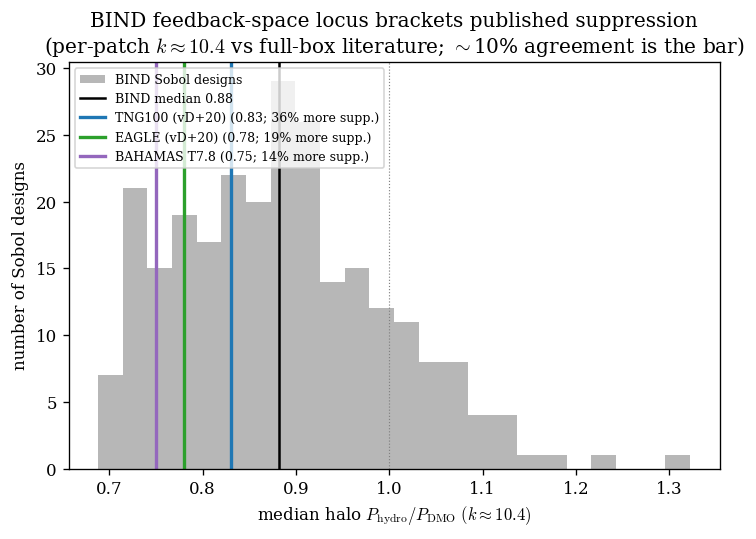

In [17]:
# 7.2 Does BIND's feedback space bracket the published suppression? (van Daalen+20)
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.hist(supp_d, bins=24, color='0.6', alpha=0.7, label='BIND Sobol designs')
ax.axvline(np.median(supp_d), color='k', lw=1.5, label=f'BIND median {np.median(supp_d):.2f}')
sty = {'TNG100 (vD+20)': 'tab:blue', 'EAGLE (vD+20)': 'tab:green', 'BAHAMAS T7.8': 'tab:purple'}
for n, v in LIT10.items():
    pct = 100 * np.mean(supp_d < v)
    ax.axvline(v, color=sty[n], lw=2, label=f'{n} ({v:.2f}; {pct:.0f}% more supp.)')
ax.axvline(1.0, color='0.5', lw=0.7, ls=':')
ax.set_xlabel(r'median halo $P_{\rm hydro}/P_{\rm DMO}\ (k\approx10.4)$')
ax.set_ylabel('number of Sobol designs')
ax.set_title('BIND feedback-space locus brackets published suppression\n'
             '(per-patch $k\\approx10.4$ vs full-box literature; $\\sim$10% agreement is the bar)')
ax.legend(fontsize=7.5, loc='upper left')
savefig(fig, 'ss_literature_bracket'); plt.show()

### 7.3 The deliverable — a suppression prior you can apply

The fitted relations invert into a usable prior: given a measured population observable,
`suppression_prior` returns the expected $P_{\rm hydro}/P_{\rm DMO}(k\approx10.4)$ with its
$1\sigma$ width $\sigma_{\rm pred}\approx0.10$. This is the actionable output of the whole
exercise — a tSZ / X-ray-informed bound on small-scale suppression, replacing an
uninformative marginalization over feedback. **Caveats:** (i) it is calibrated on
IllustrisTNG-trained BIND, so it characterizes *that model's* feedback response, not nature;
(ii) the observable must be measured in the same $<R_{200}$ aperture and mass range;
(iii) $\sigma_{\rm pred}$ is a floor — it already folds in the residual feedback freedom a
single observable cannot capture.

In [18]:
# 7.3 The deliverable: invert the calibration into an observable -> suppression prior
fit_fgas = fit_prior(fgas_d, supp_d)
fit_ym = fit_prior(dY, supp_d)

def suppression_prior(value, which='fgas'):
    """Predicted P_hydro/P_DMO(k~10.4) +/- 1 sigma for a measured population observable.
    which='fgas': value = population-median halo f_gas(<R200).
    which='ym'  : value = Y-M amplitude offset Delta log10 c0 (rel. to the design median)."""
    f = fit_fgas if which == 'fgas' else fit_ym
    return f['slope'] * value + f['intercept'], f['sigma']

print('Observable-conditioned suppression prior at k~10.4:')
print(f"  via f_gas: S = {fit_fgas['slope']:+.2f} * f_gas + {fit_fgas['intercept']:+.2f}"
      f"   +/- {fit_fgas['sigma']:.3f}")
print(f"  via Y-M  : S = {fit_ym['slope']:+.3f} * dlog10c0 + {fit_ym['intercept']:+.3f}"
      f"   +/- {fit_ym['sigma']:.3f}")
print()
rows = []
for fg in (0.06, 0.08, 0.10, 0.137, 0.16):
    mu, sg = suppression_prior(fg, 'fgas')
    rows.append({'obs_f_gas': fg, 'pred_supp': round(mu, 3), 'sigma_pred': round(sg, 3)})
    print(f'  observed median f_gas = {fg:.3f}  ->  suppression {mu:.3f} +/- {sg:.3f}')
display(pd.DataFrame(rows))

Observable-conditioned suppression prior at k~10.4:
  via f_gas: S = +2.51 * f_gas + +0.55   +/- 0.100
  via Y-M  : S = +0.509 * dlog10c0 + +0.903   +/- 0.099

  observed median f_gas = 0.060  ->  suppression 0.705 +/- 0.100
  observed median f_gas = 0.080  ->  suppression 0.755 +/- 0.100
  observed median f_gas = 0.100  ->  suppression 0.805 +/- 0.100
  observed median f_gas = 0.137  ->  suppression 0.898 +/- 0.100
  observed median f_gas = 0.160  ->  suppression 0.956 +/- 0.100


,obs_f_gas,pred_supp,sigma_pred
0,0.060,0.705,0.1
1,0.080,0.755,0.1
2,0.100,0.805,0.1
3,0.137,0.898,0.1
4,0.160,0.956,0.1
